# Setup

In [ ]:
import cuml.accel
cuml.accel.install()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
import time
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from cuml.manifold import UMAP
from sklearn.metrics import silhouette_score
from google.colab import drive
import os
import gc

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# @title
class ClusterExperimenter:
    """Experimenter class to streamline parameter sweep"""
    def __init__(self, scaled_data_path, meta_path=None):
        print(f"Loading scaled data from {scaled_data_path} ....")
        self.scaled_data = np.load(scaled_data_path)
        print(f"Loaded size: {self.scaled_data.shape}")
        self.reduced_data = None
        self.reduction_method = None
        self.results_log = []
        self.best_score = -1.0
        self.best_labels = None
        self.best_params = None

    def run_pca(self, dim=30):
        """Perform dimension reduction with PCA"""
        print(f"Performing PCA, reducing to {dim} ....")
        pca = PCA(n_components=dim, random_state=42)
        self.reduced_data = pca.fit_transform(self.scaled_data)
        print(f"Reduced size: {self.reduced_data.shape}")
        self.reduction_method = 'PCA'

        del self.scaled_data
        self.scaled_data = None
        gc.collect()
        return self.reduced_data

    def run_umap(
            self,
            dim=10,
            n_neighbors=30,
            metric='euclidean',
            should_normalize=False):
        """Perform dimension reduction with UMAP"""
        print(
            f"Performing UMAP, reducing to {dim} with n_neighnors {n_neighbors}, metric {metric} ....")
        # Instantiate reducer
        umap = UMAP(
            n_components=dim,
            n_neighbors=n_neighbors,
            metric=metric, random_state=42)

        data_to_reduce = self.scaled_data if self.scaled_data is not None else self.reduced_data

        # Reduction
        umap_reduced_data = umap.fit_transform(data_to_reduce)

        # Re-normalise the data if needed
        if should_normalize:
            print("Normalizing data ....")
            self.reduced_data = normalize(umap_reduced_data, axis=1)
            print(f"Type: {type(self.reduced_data)}")
        else:
            self.reduced_data = umap_reduced_data

        print(f"Reduced size: {self.reduced_data.shape}")
        self.reduction_method = 'UMAP'

        del self.scaled_data
        self.scaled_data = None
        gc.collect()
        return self.reduced_data

    def execute_sweep(
            self,
            param_range=None,
            val=None,
            step=None,
            min_samples=None,
            metric='euclidean',
            plot_cluster=False,
            patience=3,
            target_n_clusters = None
    ):
        """Function to sweep parameters"""
        self.results_log = []
        self.best_score = -1.0
        self.best_n_clusters = None
        total_time = 0.0

        data_to_fit = self.reduced_data if self.reduced_data is not None else self.scaled_data

        # Check data spec
        self._inspect_data(data_to_fit)

        # Prepare param trackers
        if param_range is not None and val is not None:
            raise ValueError("Cannot specify both param_range and val")
        elif param_range is not None:
            print(f"Run fixed range sweep: {param_range} with min_samples {min_samples}")
            param_to_fit = param_range
        elif val is not None and step is not None:
            print(f"Run sweep from val {val} with step {step}, min_samples {min_samples}")
            param_to_fit = None
        else:
            raise ValueError("Must specify either param_range or val")

        current_val = val
        idx = 0
        stable_count = 0
        last_n_clusters = None

        # Clustering loop
        while True:
            p = param_to_fit[idx] if param_to_fit is not None else current_val

            labels, score, n_clusters, noise_ratio, elapsed_sec = self._run_single_hdbscan(
                data_to_fit,
                p,
                min_samples,
                metric)

            total_time += elapsed_sec

            # Add a result log
            self.results_log.append({
                'param': p,
                'dbcv': score,
                'n_clusters': n_clusters,
                'noise_ratio': noise_ratio,
                'duration': elapsed_sec / 60
            })

            # Update best result in case of visualisation
            if score > self.best_score:
                self.best_score = score
                self.best_labels = labels.copy()
                self.best_params = p
                self.best_n_clusters = n_clusters

            duration_str = f"{elapsed_sec:.2f} s" if elapsed_sec < 60 else f"{elapsed_sec / 60:.2f} m"
            print(f"[{idx+1}] Val: {p} | Clusters: {n_clusters} | DBCV: {score:.4f} | Noise: {noise_ratio:.1%} | Time: {duration_str}")

            # Track plateau for stop conditions
            if n_clusters <= 1 and idx > 0:
                break
            if last_n_clusters is not None and n_clusters == last_n_clusters:
                stable_count += 1
            else:
                stable_count = 0

            # Check stop condition
            # Speed up to reach target if score stalls
            if (patience is not None and
                target_n_clusters is not None and
                step is not None and
                stable_count >= patience):

                print(f"Plateau reached. Speeding up search (Step: {step} -> {step * 2})")
                step = step * 2
                stable_count = 0

            # Stop condition A: Target reached
            elif target_n_clusters is not None and n_clusters <= target_n_clusters:
                print(f"Target cluster count {target_n_clusters} reached. Stopping.")
                break

            # Stop condition B: Patience reached (without a target)
            elif patience is not None and target_n_clusters is None and stable_count >= patience:
                print(f"Plateau reached at {n_clusters} for {patience} steps. Stopping.")
                break

            last_n_clusters = n_clusters

            if param_to_fit is not None:
                idx += 1
                if idx >= len(param_to_fit): break
            elif val is not None and step is not None:
                current_val += step
                idx += 1

        total_duration = f"{total_time:.2f} s" if total_time < 60 else f"{total_time / 60:.2f} m"
        print(f"Total Time: {total_duration}")

        # Compute the average score
        if self.results_log:
            scores = [res['dbcv'] for res in self.results_log]
            avg_score = sum(scores) / len(scores)

            print("-" * 30)
            print(f"SWEEP SUMMARY:")
            print(f"Total iterations: {len(self.results_log)}")
            print(f"Best DBCV: {self.best_score:.4f} with {self.best_n_clusters}")
            print(f"Average DBCV: {avg_score:.4f}")

        # Visualise the result log
        self._plot_results()

        # Visualise the clusters if requested
        if self.best_labels is not None and plot_cluster:
            self.plot_clusters(self.best_labels)

    def _run_single_hdbscan(self, data, p_val, min_samples, metric):
        """HDBSCAN execution"""
        start_time = time.time()

        # If min_sample is left equal to mcs, limit to 1023 maximum
        if min_samples is None:
            min_samples = min(p_val, 1023)

        model = hdbscan.HDBSCAN(
                min_cluster_size=p_val,
                min_samples=min_samples,
                metric=metric,
                gen_min_span_tree=True
        )

        labels = model.fit_predict(data)
        score = model.relative_validity_

        valid_labels = labels[labels != -1]
        n_clusters = len(np.unique(valid_labels))
        noise_ratio = np.sum(labels == -1 ) / len(labels)
        elapsed_sec = time.time() - start_time

        return labels, score, n_clusters, noise_ratio, elapsed_sec

    def _inspect_data(self, data_var):
        """Check dataset spec"""
        print("-" * 30)
        print(f"Object Type: {type(data_var)}")
        if hasattr(data_var, 'shape'):
            print(f"Dimensions:  {data_var.shape}")
        if hasattr(data_var, 'dtype'):
            print(f"Value Type:  {data_var.dtype}")
        print("-" * 30)

    def export_results_csv(self, filename="sweep_results.csv"):
        """Save the results_log list as a CSV file"""
        if not self.results_log:
            print("No results to export.")
            return

        df_results = pd.DataFrame(self.results_log)

        summary_row = {
            'param': 'Average',
            'dbcv': df_results['dbcv'].mean(),
            'n_clusters': '',
            'noise_ratio': '',
            'duration': df_results['duration'].sum()
        }

        best_row = {
            'param': 'Best',
            'dbcv': self.best_score,
            'n_clusters': self.best_n_clusters,
            'noise_ratio': '',
            'duration': ''
        }

        df_summary = pd.DataFrame([summary_row])
        df_best = pd.DataFrame([best_row])
        df_final = pd.concat([df_results, df_summary, df_best], ignore_index=True)

        # Save to Drive/Local
        df_final.to_csv(filename, index=False)

        print(f"Results exported to {filename}")

    def _plot_results(self):
        """Plot dbcv scores"""
        df = pd.DataFrame(self.results_log)
        fig, ax1 = plt.subplots(figsize=(12, 6))

        color = 'tab:blue'
        ax1.set_xlabel('Param value (MCS)')
        ax1.set_ylabel('DBCV', color=color)
        ax1.plot(df['param'], df['dbcv'], marker='o', color=color, linewidth=3, label='DBCV')
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel("Number of clusters found", color=color)
        ax2.plot(df['param'], df['n_clusters'], marker='s', linestyle='--', color=color, label='Clusters')
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f"HDBSCAN results")
        fig.tight_layout()
        plt.grid(alpha=0.3)
        plt.show()

    def plot_clusters(self, labels, reducer='pca', xlim=None, ylim=None):
        print("Plotting data ....")
        data_to_plot = self.reduced_data if self.reduced_data is not None else self.scaled_data

        if data_to_plot.shape[1] > 2:
            print(f"Reducing data to 2D using {reducer}")
            if reducer == 'pca':
                reducer = PCA(n_components=2, random_state=42)
            else:
                reducer = UMAP(n_neighbors=100, random_state=42)
            embedding_2d = reducer.fit_transform(data_to_plot)
        else:
            embedding_2d = data_to_plot
            reducer = "Raw 2D"

        plt.figure(figsize=(14, 9))

        # Separate Noise (-1) from Clusters for better visual layering
        is_noise = (labels == -1)
        cluster_data = embedding_2d[~is_noise]
        cluster_labels = labels[~is_noise]
        noise_data = embedding_2d[is_noise]

        # Plot Noise first (in background)
        plt.scatter(noise_data[:, 0], noise_data[:, 1],
                    c='grey', s=1, alpha=0.4, label='Noise')

        # Plot Clusters (in foreground)
        scatter = plt.scatter(
            cluster_data[:, 0],
            cluster_data[:, 1],
            c=cluster_labels,
            cmap='Spectral',
            s=0.5,
            alpha=0.2)

        # 4. Aesthetics
        n_clusters = len(np.unique(cluster_labels))
        noise_pct = (np.sum(is_noise) / len(labels)) * 100

        plt.title(f"HDBSCAN Clusters ({n_clusters} clusters)\n"
                  f"Reduction: {reducer} | Noise: {noise_pct:.1f}%", fontsize=14)
        plt.xlabel(f"{reducer} Axis 1")
        plt.ylabel(f"{reducer} Axis 2")

        if (xlim is not None) and (ylim is not None):
            plt.xlim(xlim[0], xlim[1])
            plt.ylim(ylim[0], ylim[1])

        # Optional: Add colorbar for Cluster IDs
        if n_clusters < 50:
            plt.colorbar(scatter, label='Cluster ID')

        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()

        # filename = f"cluster_viz_{reducer_type.lower()}.png"
        # plt.savefig(filename, dpi=300)
        # print(f"Visualization saved to {filename}")
        plt.show()

    def save_best_result(self, csv_path, par_path):
        df = pd.read_csv(csv_path, index_col=0)
        df['cluster_id'] = self.best_labels
        df.to_parquet(par_path)
        df.head()

In [ ]:
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/CMS_PRO-Explainable_Clustering/'
PROCESSED_DATA_DIR = DATA_DIR + 'data/processed/'
LOG_DIR = PROCESSED_DATA_DIR + 'Result Logs/'

Mounted at /content/drive


# Topical (Thematic)

In [ ]:
topical_features_path = os.path.join(PROCESSED_DATA_DIR, 'topical_features.npy')

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 15, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1679 | DBCV: 0.4453 | Noise: 22.0% | Time: 1.17 m
[2] Val: 250 | Clusters: 292 | DBCV: 0.2439 | Noise: 39.1% | Time: 1.16 m
[3] Val: 450 | Clusters: 134 | DBCV: 0.2014 | Noise: 40.9% | Time: 59.31 s
[4] Val: 650 | Clusters: 98 | DBCV: 0.1728 | Noise: 41.7% | Time: 55.06 s
[5] Val: 850 | Clusters: 66 | DBCV: 0.1909 | Noise: 44.0% | Time: 59.21 s
[6] Val: 1050 | Clusters: 42 | DBCV: 0.1484 | Noise: 46.8% | Time: 54.91 s
[7] Val: 1250 | Clusters: 34 | DBCV: 0.1553 | Noise: 46.8% | Time: 54

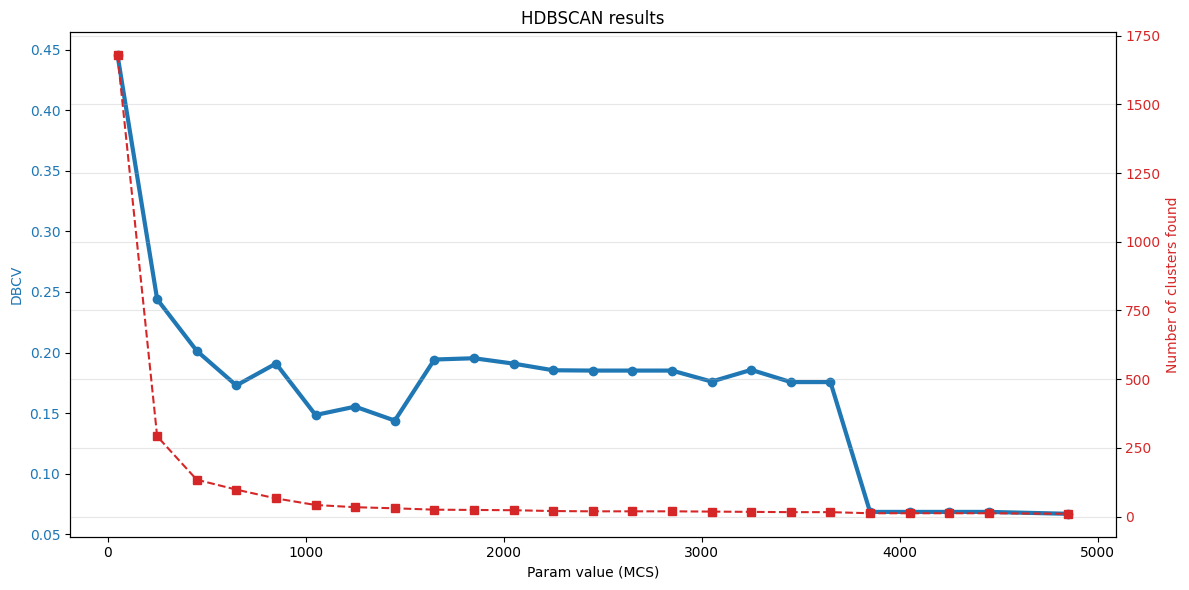

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_10_15.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        24 │   18m38s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        24 │   18m38s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=10, umap n_neighbors=15
with cuml.accel.profile():
    exp_tp_1_10_15 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_15.run_umap(dim=10, n_neighbors=15, metric='cosine', should_normalize=True)
    exp_tp_1_10_15.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_15.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_10_15.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 30, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1583 | DBCV: 0.4953 | Noise: 15.5% | Time: 47.06 s
[2] Val: 250 | Clusters: 313 | DBCV: 0.2472 | Noise: 34.3% | Time: 45.20 s
[3] Val: 450 | Clusters: 139 | DBCV: 0.2001 | Noise: 40.6% | Time: 46.77 s
[4] Val: 650 | Clusters: 92 | DBCV: 0.1612 | Noise: 44.2% | Time: 45.97 s
[5] Val: 850 | Clusters: 64 | DBCV: 0.1362 | Noise: 45.0% | Time: 45.69 s
[6] Val: 1050 | Clusters: 49 | DBCV: 0.1435 | Noise: 45.3% | Time: 46.74 s
[7] Val: 1250 | Clusters: 36 | DBCV: 0.1069 | Noise: 40.4% | Time: 

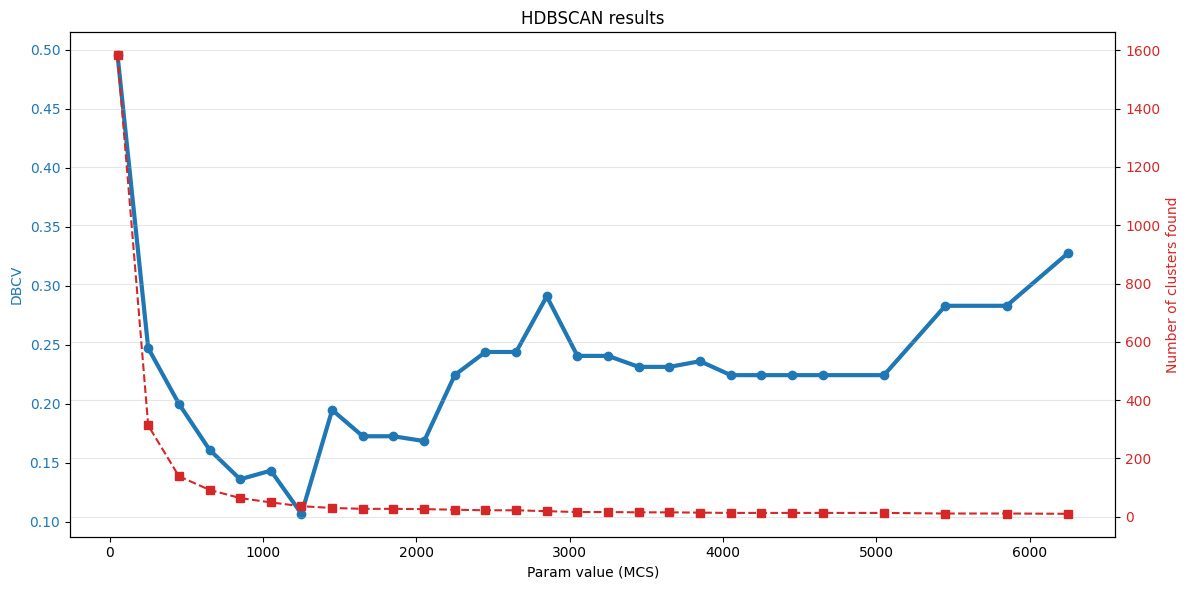

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_10_30.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        28 │   17m26s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        28 │   17m26s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=10, umap n_neighbors=30
with cuml.accel.profile():
    exp_tp_1_10_30 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_30.run_umap(dim=10, n_neighbors=30, metric='cosine', should_normalize=True)
    exp_tp_1_10_30.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_30.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_10_30.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 50, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1494 | DBCV: 0.5063 | Noise: 14.3% | Time: 47.94 s
[2] Val: 250 | Clusters: 327 | DBCV: 0.2854 | Noise: 29.7% | Time: 45.45 s
[3] Val: 450 | Clusters: 148 | DBCV: 0.2279 | Noise: 37.6% | Time: 47.07 s
[4] Val: 650 | Clusters: 108 | DBCV: 0.2096 | Noise: 40.4% | Time: 46.95 s
[5] Val: 850 | Clusters: 72 | DBCV: 0.2039 | Noise: 40.6% | Time: 45.50 s
[6] Val: 1050 | Clusters: 51 | DBCV: 0.1819 | Noise: 44.3% | Time: 46.98 s
[7] Val: 1250 | Clusters: 42 | DBCV: 0.1755 | Noise: 46.2% | Time:

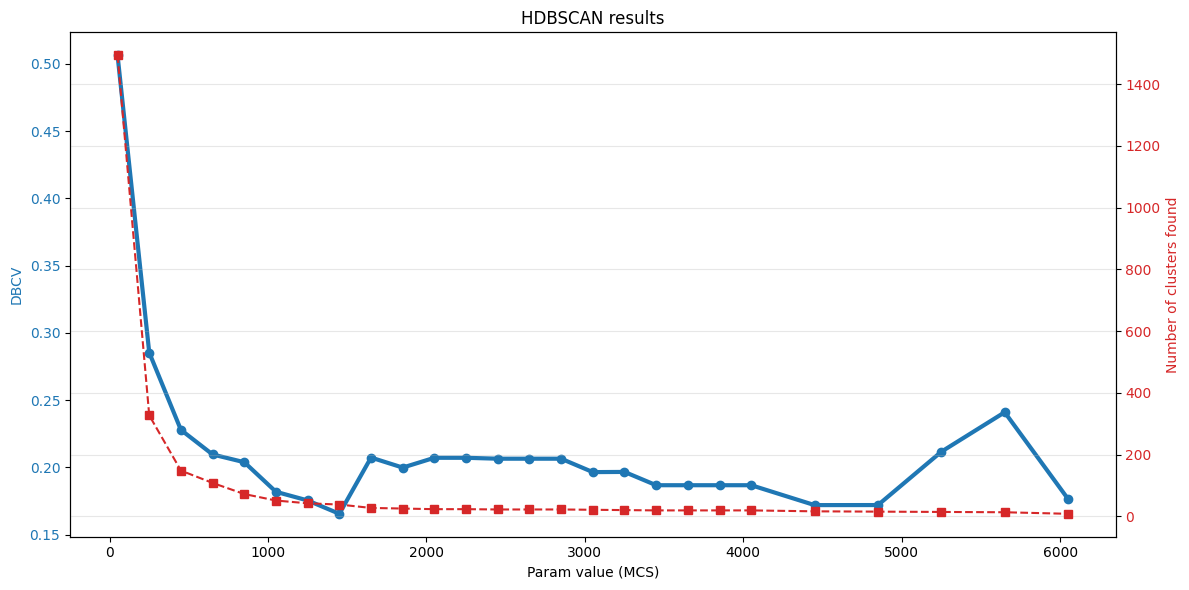

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_10_50.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        26 │   16m18s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        26 │   16m18s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=10, umap n_neighbors=50
with cuml.accel.profile():
    exp_tp_1_10_50 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_50.run_umap(dim=10, n_neighbors=50, metric='cosine', should_normalize=True)
    exp_tp_1_10_50.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_50.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_10_50.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1284 | DBCV: 0.5344 | Noise: 13.2% | Time: 45.47 s
[2] Val: 250 | Clusters: 342 | DBCV: 0.3783 | Noise: 25.7% | Time: 45.68 s
[3] Val: 450 | Clusters: 157 | DBCV: 0.2242 | Noise: 34.4% | Time: 46.19 s
[4] Val: 650 | Clusters: 118 | DBCV: 0.2056 | Noise: 37.2% | Time: 45.07 s
[5] Val: 850 | Clusters: 79 | DBCV: 0.2040 | Noise: 39.5% | Time: 44.80 s
[6] Val: 1050 | Clusters: 59 | DBCV: 0.1949 | Noise: 40.5% | Time: 46.32 s
[7] Val: 1250 | Clusters: 48 | DBCV: 0.2089 | Noise: 41.7% | Time

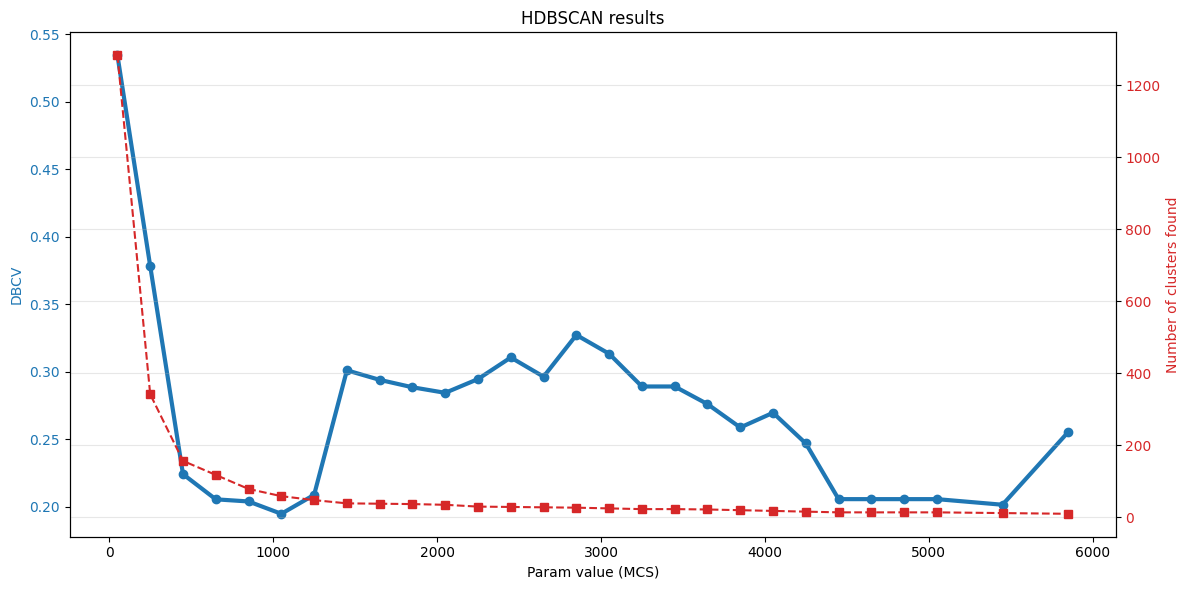

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_10_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        28 │ 17m12.6s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        28 │ 17m12.6s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=10, umap n_neighbors=200
with cuml.accel.profile():
    exp_tp_1_10_200 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_200.run_umap(dim=10, n_neighbors=200, metric='cosine', should_normalize=True)
    exp_tp_1_10_200.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_10_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 200, metric euclidean ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1261 | DBCV: 0.6495 | Noise: 12.5% | Time: 42.72 s
[2] Val: 250 | Clusters: 339 | DBCV: 0.3246 | Noise: 27.4% | Time: 41.81 s
[3] Val: 450 | Clusters: 142 | DBCV: 0.2464 | Noise: 34.6% | Time: 42.07 s
[4] Val: 650 | Clusters: 109 | DBCV: 0.2320 | Noise: 36.7% | Time: 41.78 s
[5] Val: 850 | Clusters: 80 | DBCV: 0.1715 | Noise: 37.2% | Time: 42.03 s
[6] Val: 1050 | Clusters: 62 | DBCV: 0.1609 | Noise: 40.5% | Time: 42.09 s
[7] Val: 1250 | Clusters: 53 | DBCV: 0.1510 | Noise: 37.0% | T

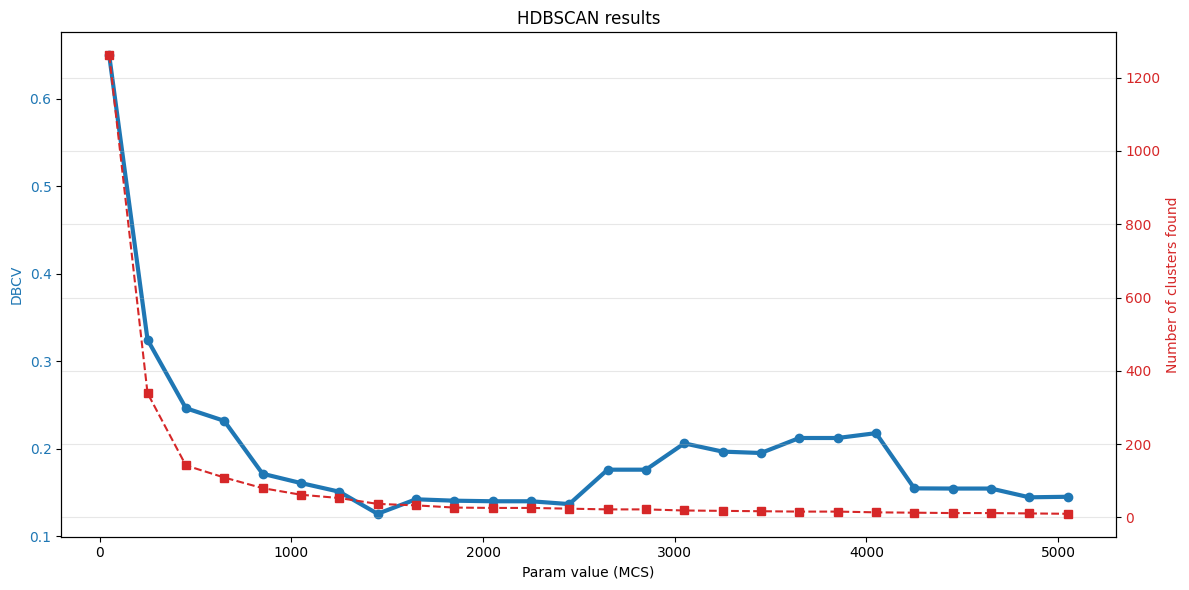

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_eu10_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        26 │  14m0.1s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        26 │  14m0.1s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# reduction method: euclidean
with cuml.accel.profile():
    exp_tp_1_10_200 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_200.run_umap(dim=10, n_neighbors=200, should_normalize=True)
    exp_tp_1_10_200.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_eu10_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 500, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1256 | DBCV: 0.5158 | Noise: 14.2% | Time: 45.86 s
[2] Val: 250 | Clusters: 320 | DBCV: 0.3239 | Noise: 26.9% | Time: 45.25 s
[3] Val: 450 | Clusters: 170 | DBCV: 0.2589 | Noise: 34.3% | Time: 46.39 s
[4] Val: 650 | Clusters: 106 | DBCV: 0.2019 | Noise: 37.3% | Time: 45.41 s
[5] Val: 850 | Clusters: 82 | DBCV: 0.1767 | Noise: 38.4% | Time: 44.77 s
[6] Val: 1050 | Clusters: 66 | DBCV: 0.1679 | Noise: 41.6% | Time: 46.27 s
[7] Val: 1250 | Clusters: 53 | DBCV: 0.1804 | Noise: 43.8% | Time

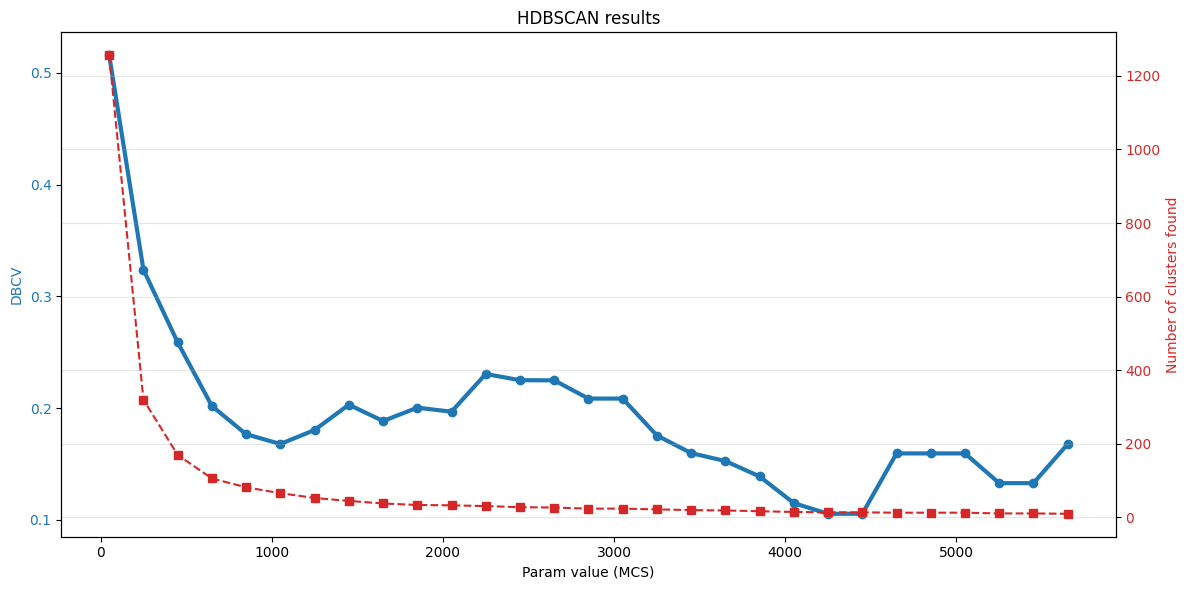

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_10_500.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        29 │   17m52s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        29 │   17m52s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=10, umap n_neighbors=500
with cuml.accel.profile():
    exp_tp_1_10_500 = ClusterExperimenter(topical_features_path)
    exp_tp_1_10_500.run_umap(dim=10, n_neighbors=500, metric='cosine', should_normalize=True)
    exp_tp_1_10_500.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_10_500.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_10_500.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 30 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 30)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 30)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1437 | DBCV: 0.6322 | Noise: 16.3% | Time: 53.09 s
[2] Val: 250 | Clusters: 365 | DBCV: 0.4196 | Noise: 27.0% | Time: 53.38 s
[3] Val: 450 | Clusters: 174 | DBCV: 0.3212 | Noise: 33.9% | Time: 53.78 s
[4] Val: 650 | Clusters: 124 | DBCV: 0.2862 | Noise: 36.9% | Time: 54.15 s
[5] Val: 850 | Clusters: 93 | DBCV: 0.2364 | Noise: 39.1% | Time: 54.03 s
[6] Val: 1050 | Clusters: 69 | DBCV: 0.2481 | Noise: 40.1% | Time: 54.03 s
[7] Val: 1250 | Clusters: 57 | DBCV: 0.2762 | Noise: 42.5% | Time

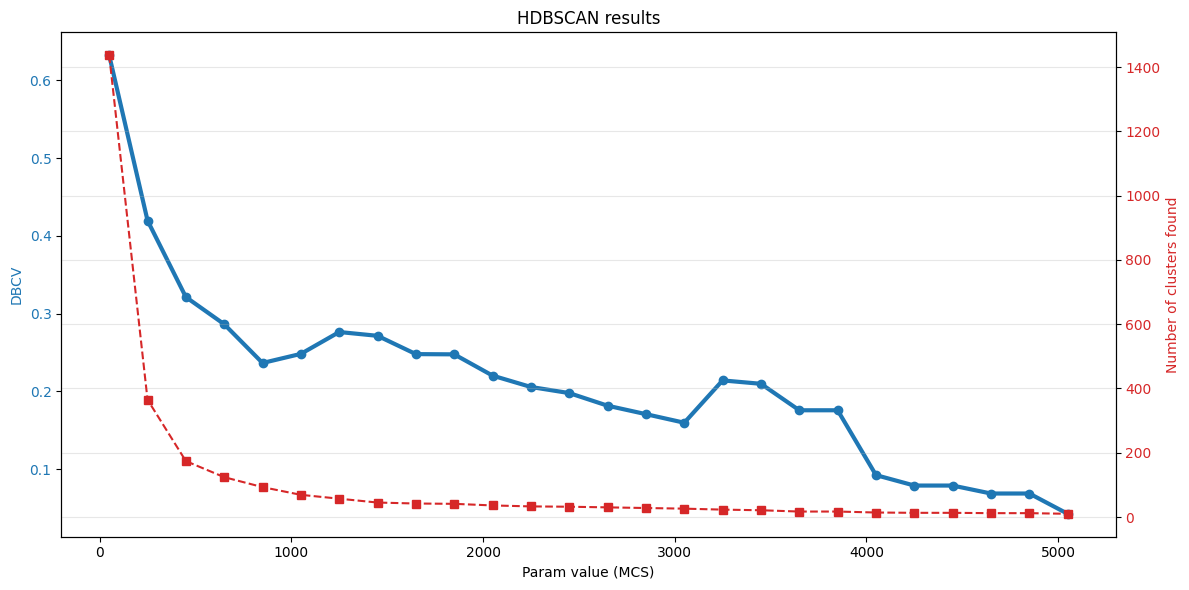

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_1_30_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        26 │ 19m23.4s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        26 │ 19m23.4s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=1, umap dim=30, umap n_neighbors=200
with cuml.accel.profile():
    exp_tp_1_30_200 = ClusterExperimenter(topical_features_path)
    exp_tp_1_30_200.run_umap(dim=30, n_neighbors=200, metric='cosine', should_normalize=True)
    exp_tp_1_30_200.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_1_30_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_30_200.csv"))

In [ ]:
# # min_samples=1, umap dim=178, umap n_neighbors=200
# with cuml.accel.profile():
#     exp_tp_1_178_200 = ClusterExperimenter(topical_features_path)
#     exp_tp_1_178_200.run_umap(dim=178, n_neighbors=200, metric='cosine', should_normalize=True)
#     exp_tp_1_178_200.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
#     exp_tp_1_178_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_1_178_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 178 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 178)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 178)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │         1 │  2m51.7s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │         1 │  2m51.7s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

KeyboardInterrupt: 

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 30 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 30)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 30)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1404 | DBCV: 0.4826 | Noise: 19.8% | Time: 36.99 s
[2] Val: 250 | Clusters: 356 | DBCV: 0.4067 | Noise: 29.6% | Time: 36.85 s
[3] Val: 450 | Clusters: 168 | DBCV: 0.3092 | Noise: 36.8% | Time: 35.39 s
[4] Val: 650 | Clusters: 120 | DBCV: 0.2761 | Noise: 39.2% | Time: 36.66 s
[5] Val: 850 | Clusters: 89 | DBCV: 0.2921 | Noise: 42.5% | Time: 36.18 s
[6] Val: 1050 | Clusters: 71 | DBCV: 0.2883 | Noise: 45.3% | Time: 35.97 s
[7] Val: 1250 | Clusters: 54 | DBCV: 0.3072 | Noise: 47.4% | Tim

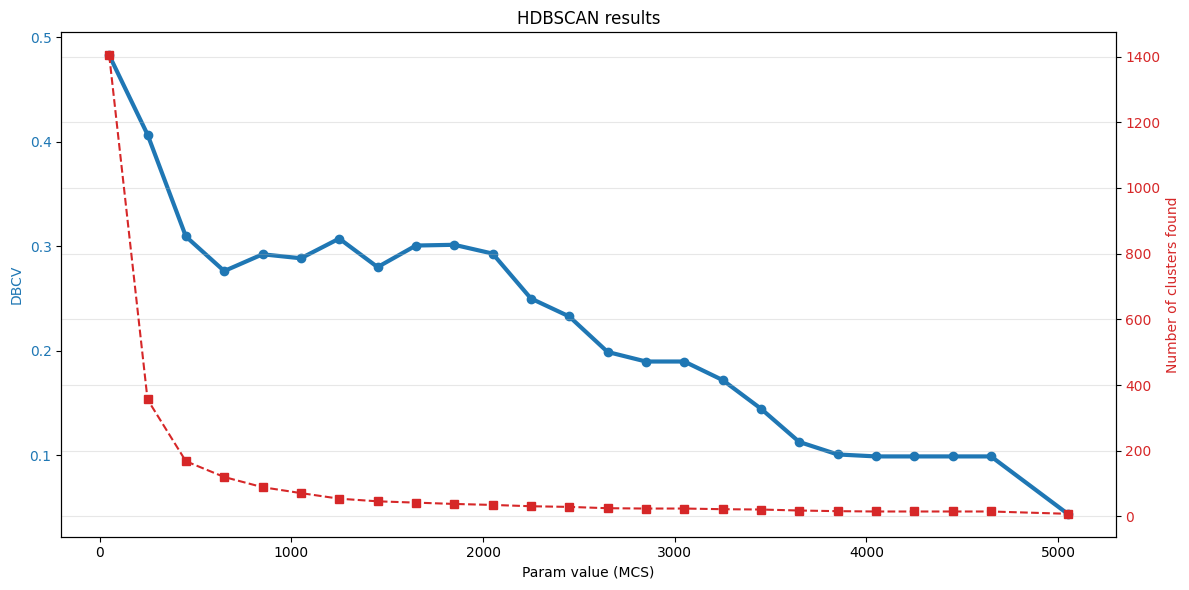

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_13_30_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        25 │ 11m25.6s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        25 │ 11m25.6s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=13, umap dim=30, umap n_neighbors=200
with cuml.accel.profile():
    exp_tp_13_30_200 = ClusterExperimenter(topical_features_path)
    exp_tp_13_30_200.run_umap(dim=30, n_neighbors=200, metric='cosine', should_normalize=True)
    exp_tp_13_30_200.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tp_13_30_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_13_30_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 30 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 30)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 30)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 5
[1] Val: 50 | Clusters: 1418 | DBCV: 0.4603 | Noise: 17.7% | Time: 38.84 s
[2] Val: 250 | Clusters: 349 | DBCV: 0.3718 | Noise: 28.8% | Time: 39.29 s
[3] Val: 450 | Clusters: 162 | DBCV: 0.2785 | Noise: 39.1% | Time: 39.26 s
[4] Val: 650 | Clusters: 114 | DBCV: 0.2685 | Noise: 40.8% | Time: 38.59 s
[5] Val: 850 | Clusters: 85 | DBCV: 0.2270 | Noise: 45.0% | Time: 37.69 s
[6] Val: 1050 | Clusters: 64 | DBCV: 0.2103 | Noise: 47.4% | Time: 38.57 s
[7] Val: 1250 | Clusters: 55 | DBCV: 0.2087 | Noise: 50.0% | Time

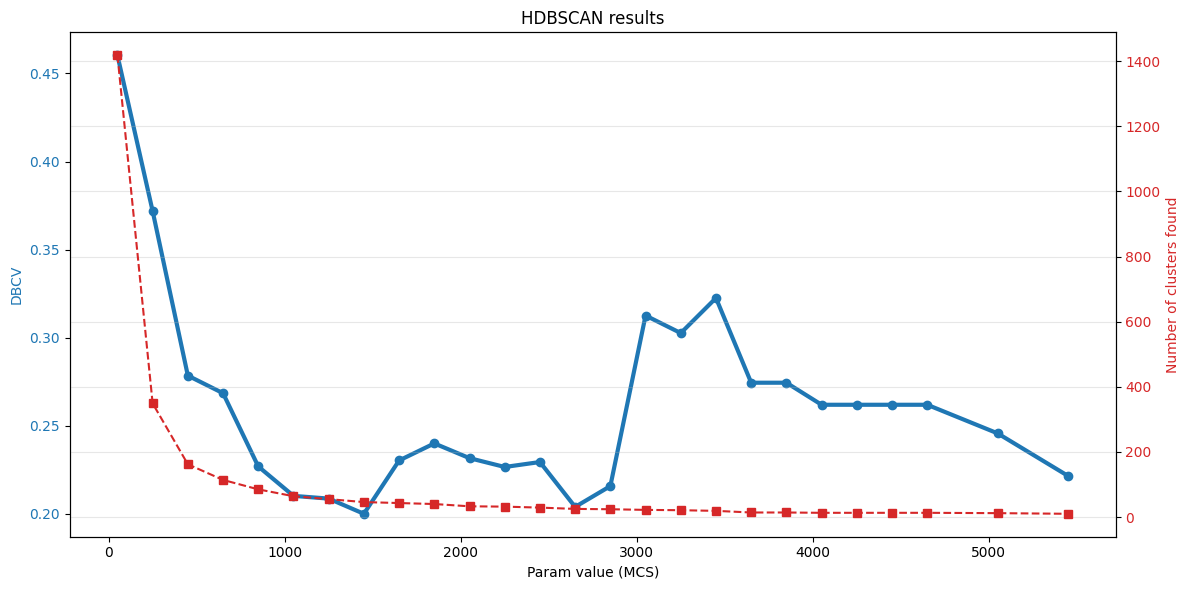

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_5_30_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        26 │ 12m52.1s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        26 │ 12m52.1s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=5, umap dim=30, umap n_neighbors=200
with cuml.accel.profile():
    exp_tp_5_30_200 = ClusterExperimenter(topical_features_path)
    exp_tp_5_30_200.run_umap(dim=30, n_neighbors=200, metric='cosine', should_normalize=True)
    exp_tp_5_30_200.execute_sweep(val=50, step=200, min_samples=5, target_n_clusters=10)
    exp_tp_5_30_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_5_30_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1217 | DBCV: 0.4526 | Noise: 16.5% | Time: 31.42 s
[2] Val: 250 | Clusters: 328 | DBCV: 0.3345 | Noise: 27.8% | Time: 32.28 s
[3] Val: 450 | Clusters: 152 | DBCV: 0.2510 | Noise: 36.7% | Time: 32.89 s
[4] Val: 650 | Clusters: 113 | DBCV: 0.2169 | Noise: 38.4% | Time: 31.21 s
[5] Val: 850 | Clusters: 79 | DBCV: 0.1762 | Noise: 41.4% | Time: 32.33 s
[6] Val: 1050 | Clusters: 62 | DBCV: 0.1806 | Noise: 43.9% | Time: 32.54 s
[7] Val: 1250 | Clusters: 48 | DBCV: 0.2523 | Noise: 43.8% | Tim

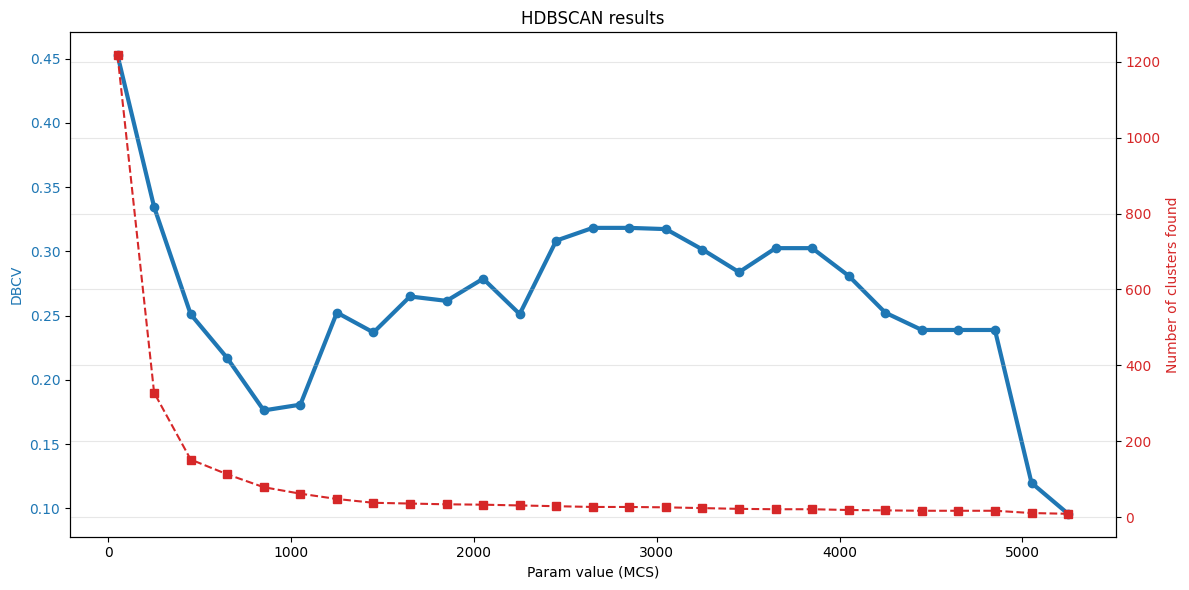

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_13_10_200.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        27 │ 10m28.9s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        27 │ 10m28.9s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# min_samples=13, umap dim=10, umap n_neighbors=200
with cuml.accel.profile():
    exp_tp_13_10_200 = ClusterExperimenter(topical_features_path)
    exp_tp_13_10_200.run_umap(dim=10, n_neighbors=200, metric='cosine', should_normalize=True)
    exp_tp_13_10_200.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tp_13_10_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_13_10_200.csv"))

In [ ]:
# # min_samples=na, umap dim=10, umap n_neighbors=200
# with cuml.accel.profile():
#     exp_tp_na_10_200 = ClusterExperimenter(topical_features_path)
#     exp_tp_na_10_200.run_umap(dim=10, n_neighbors=200, metric='cosine', should_normalize=True)
#     exp_tp_na_10_200.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tp_na_10_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_na_10_200.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 10)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples None
[1] Val: 50 | Clusters: 1112 | DBCV: 0.4099 | Noise: 21.0% | Time: 31.18 s
[2] Val: 250 | Clusters: 287 | DBCV: 0.2956 | Noise: 38.4% | Time: 40.26 s
[3] Val: 450 | Clusters: 130 | DBCV: 0.1921 | Noise: 46.5% | Time: 2.23 m


In [ ]:
# min_samples=na, umap dim=30, umap n_neighbors=200
# with cuml.accel.profile():
#     exp_tp_na_30_200 = ClusterExperimenter(topical_features_path)
#     exp_tp_na_30_200.run_umap(dim=30, n_neighbors=200, metric='cosine', should_normalize=True)
#     exp_tp_na_30_200.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tp_na_30_200.export_results_csv(os.path.join(LOG_DIR, "exp_tp_na_30_200.csv"))

# Spatial

## 2D Coordinates

In [ ]:
RAD_FEATURE_DIR = '2D_spatial_features.npy'
spatial_features_path = os.path.join(PROCESSED_DATA_DIR, RAD_FEATURE_DIR)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/spatial_rad_features.npy ....
Loaded size: (278631, 2)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (278631, 2)
Value Type:  float64
------------------------------
Run fixed range sweep: [1500] with min_samples 1
[1] Val: 1500 | Clusters: 3 | DBCV: 0.0203 | Noise: 0.8% | Time: 5.97 m
Total Time: 5.97 m


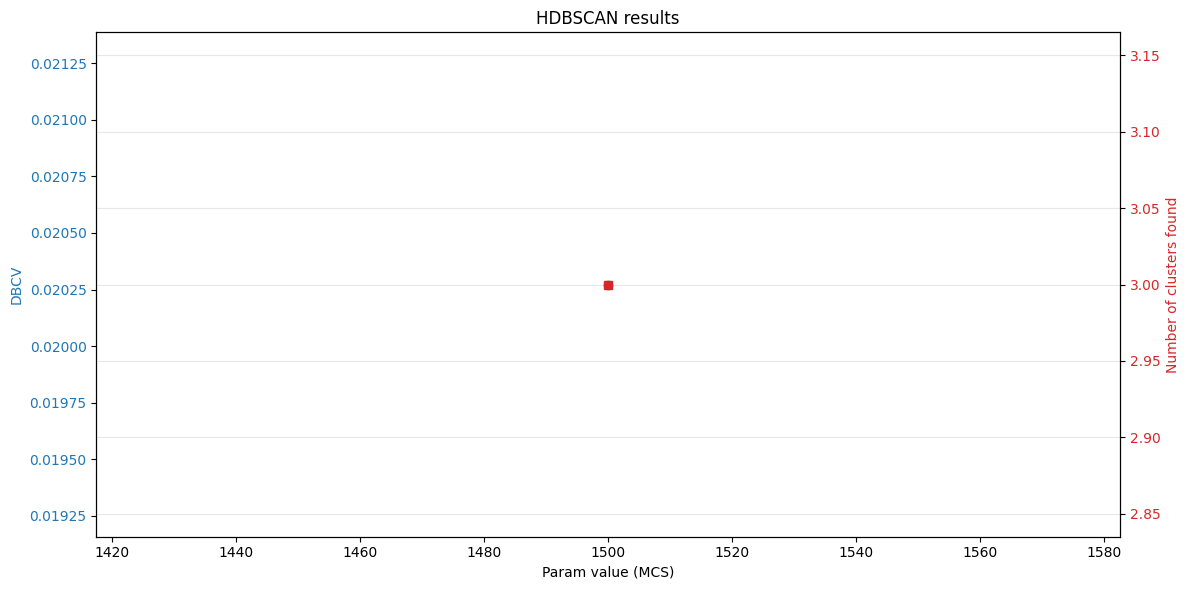

Plotting data ....


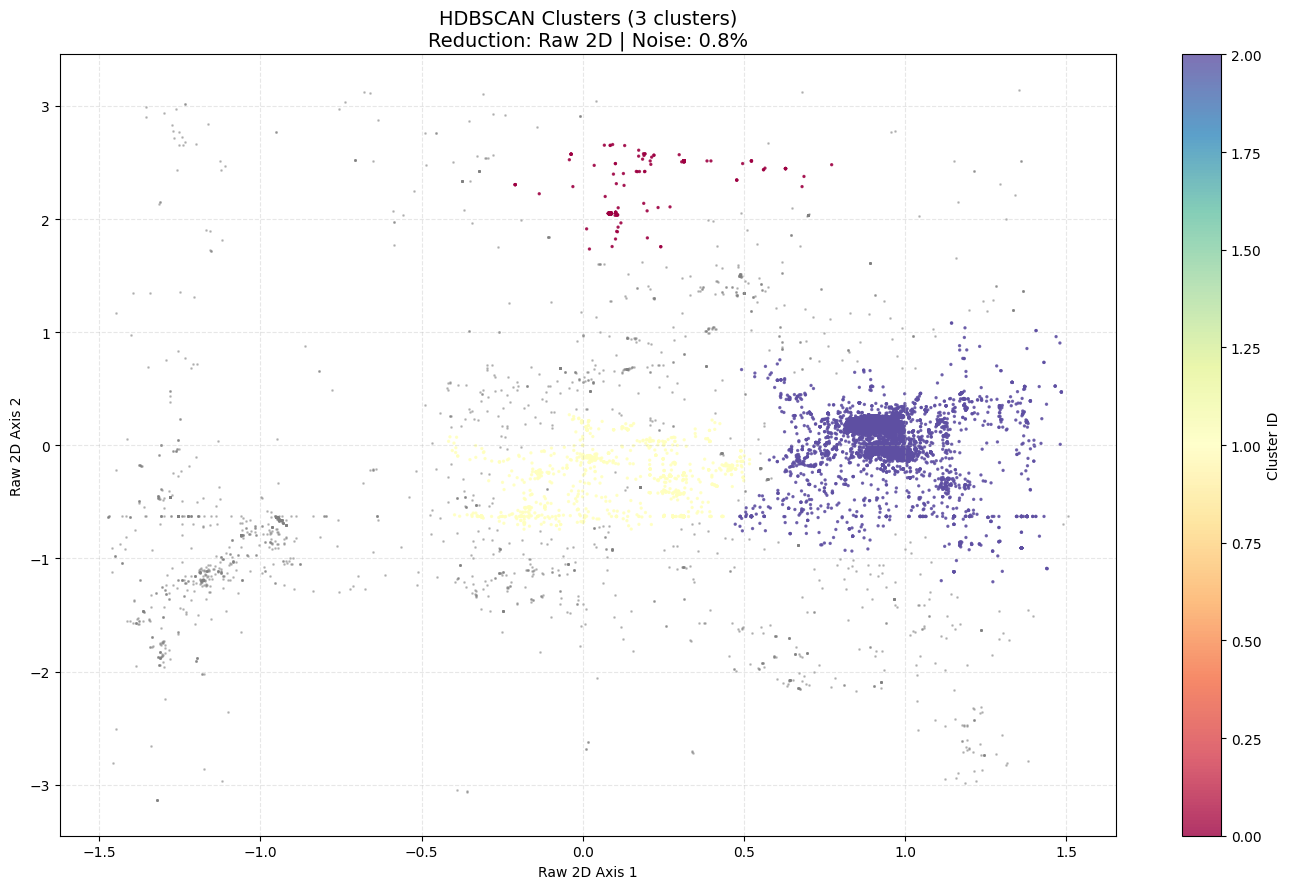

In [ ]:
# Data: 2D coordinates -> rad, hdbscan metric=haversine
# with cuml.accel.profile():
# exp_sp_na_hvsine = ClusterExperimenter(spatial_features_path)
# exp_sp_na_hvsine.execute_sweep(param_range=[1500], min_samples=1, metric='haversine', plot_cluster=True)

## Sinusoidal encoded 4D

In [ ]:
spatial_features_path = os.path.join(PROCESSED_DATA_DIR, 'sinu_spatial_features.npy')

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/sinu_spatial_features.npy ....
Loaded size: (300765, 4)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 4)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 369 | DBCV: 0.1233 | Noise: 5.2% | Time: 33.00 s
[2] Val: 250 | Clusters: 105 | DBCV: 0.1037 | Noise: 9.6% | Time: 33.65 s
[3] Val: 450 | Clusters: 68 | DBCV: 0.0878 | Noise: 11.0% | Time: 30.75 s
[4] Val: 650 | Clusters: 49 | DBCV: 0.0724 | Noise: 12.6% | Time: 32.46 s
[5] Val: 850 | Clusters: 40 | DBCV: 0.0700 | Noise: 14.2% | Time: 33.00 s
[6] Val: 1050 | Clusters: 36 | DBCV: 0.0720 | Noise: 14.9% | Time: 31.20 s
[7] Val: 1250 | Clusters: 30 | DBCV: 0.0698 | Noise: 14.4% | Time: 32.14 s
[8] Val: 1450 | Clusters: 23 | DBCV: 0.0435 | Noise: 16.2% | Time: 32.45 s
[9] Val: 1650 | Clusters: 21 | DBCV: 0.0353 | Noise: 17.2% | Time: 31.

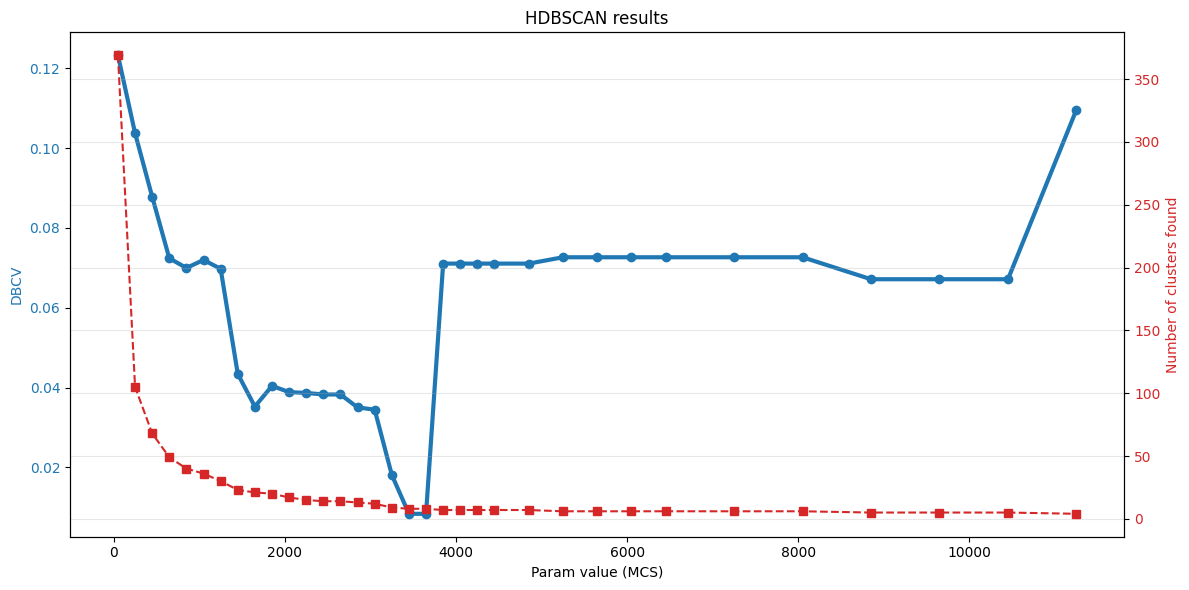

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_sp_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        34 │  13m7.7s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        34 │  13m7.7s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Data: 4D sinusoidal, min_samples=1
with cuml.accel.profile():
    exp_sp_1 = ClusterExperimenter(spatial_features_path)
    exp_sp_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=4)
    exp_sp_1.export_results_csv(os.path.join(LOG_DIR, "exp_sp_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/sinu_spatial_features.npy ....
Loaded size: (300765, 4)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 4)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 350 | DBCV: 0.1300 | Noise: 10.3% | Time: 22.91 s
[2] Val: 250 | Clusters: 102 | DBCV: 0.0940 | Noise: 12.6% | Time: 22.88 s
[3] Val: 450 | Clusters: 68 | DBCV: 0.0890 | Noise: 15.2% | Time: 23.77 s
[4] Val: 650 | Clusters: 47 | DBCV: 0.0681 | Noise: 18.2% | Time: 22.45 s
[5] Val: 850 | Clusters: 35 | DBCV: 0.1427 | Noise: 17.6% | Time: 23.01 s
[6] Val: 1050 | Clusters: 28 | DBCV: 0.1035 | Noise: 18.1% | Time: 23.57 s
[7] Val: 1250 | Clusters: 25 | DBCV: 0.0920 | Noise: 19.4% | Time: 22.31 s
[8] Val: 1450 | Clusters: 21 | DBCV: 0.0761 | Noise: 21.1% | Time: 23.24 s
[9] Val: 1650 | Clusters: 21 | DBCV: 0.0761 | Noise: 21.1% | Time: 

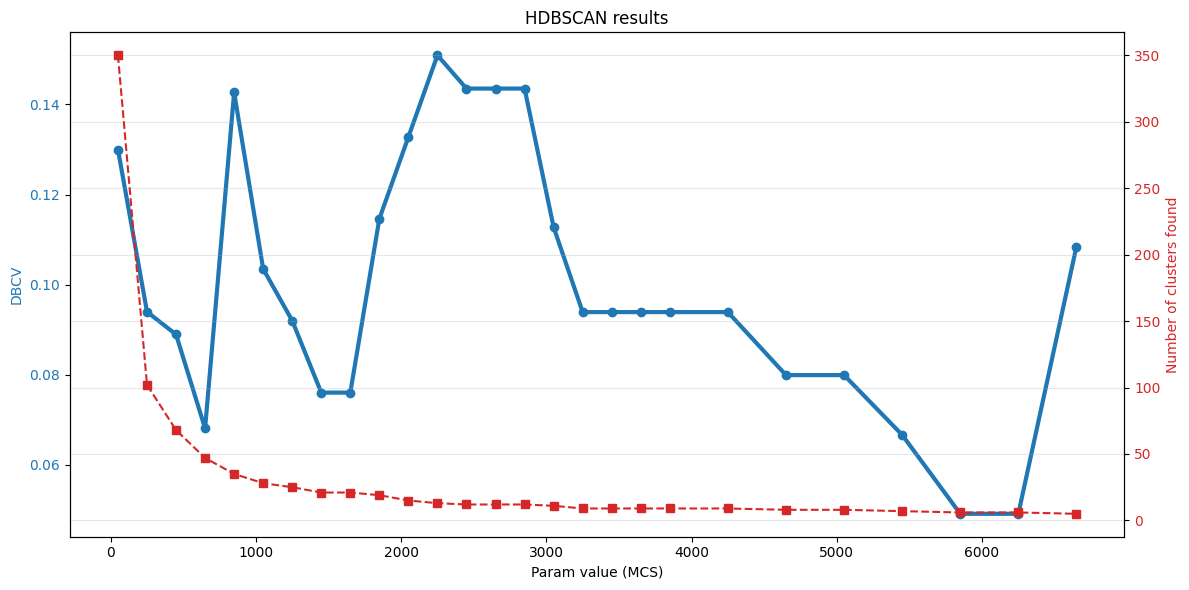

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_sp_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        27 │  6m18.9s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        27 │  6m18.9s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Data: 4D sinusoidal, min_samples=13
with cuml.accel.profile():
    exp_sp_13 = ClusterExperimenter(spatial_features_path)
    exp_sp_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=5)
    exp_sp_13.export_results_csv(os.path.join(LOG_DIR, "exp_sp_13.csv"))

In [ ]:
# # Data: 4D sinusoidal, min_samples=na
# with cuml.accel.profile():
#     exp_sp_na = ClusterExperimenter(spatial_features_path)
#     exp_sp_na.execute_sweep(val=50, step=200, target_n_clusters=5)
#     exp_sp_na.export_results_csv(os.path.join(LOG_DIR, "exp_sp_na.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/sinu_spatial_features.npy ....
Loaded size: (300765, 4)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 4)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples None
[1] Val: 50 | Clusters: 442 | DBCV: 0.1272 | Noise: 19.2% | Time: 24.66 s
[2] Val: 250 | Clusters: 162 | DBCV: 0.1815 | Noise: 35.3% | Time: 39.29 s
[3] Val: 450 | Clusters: 105 | DBCV: 0.1376 | Noise: 42.7% | Time: 2.03 m


In [ ]:
    # exp_sp_na.plot_clusters(exp_sp_na.best_labels, reducer='umap')

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/sinu_spatial_features.npy ....
Loaded size: (300765, 4)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 4)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 5
[1] Val: 50 | Clusters: 276 | DBCV: 0.0986 | Noise: 6.4% | Time: 22.79 s
[2] Val: 250 | Clusters: 76 | DBCV: 0.1168 | Noise: 9.6% | Time: 23.95 s
[3] Val: 450 | Clusters: 54 | DBCV: 0.1093 | Noise: 9.6% | Time: 23.74 s
[4] Val: 650 | Clusters: 36 | DBCV: 0.1794 | Noise: 11.4% | Time: 23.02 s
[5] Val: 850 | Clusters: 30 | DBCV: 0.1422 | Noise: 11.8% | Time: 23.52 s
[6] Val: 1050 | Clusters: 26 | DBCV: 0.1306 | Noise: 13.0% | Time: 24.04 s
[7] Val: 1250 | Clusters: 22 | DBCV: 0.1149 | Noise: 13.7% | Time: 22.85 s
[8] Val: 1450 | Clusters: 16 | DBCV: 0.0661 | Noise: 15.0% | Time: 22.99 s
[9] Val: 1650 | Clusters: 16 | DBCV: 0.0661 | Noise: 15.0% | Time: 24.14

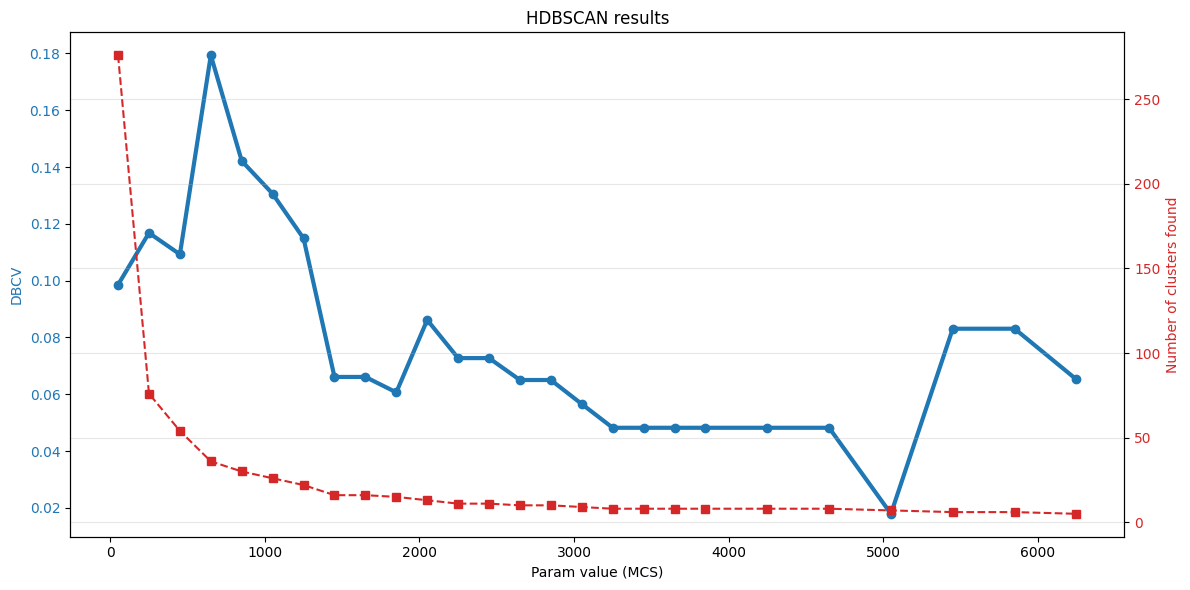

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_sp_5.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        26 │  6m18.9s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        26 │  6m18.9s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Data: 4D sinusoidal, min_samples=5
with cuml.accel.profile():
    exp_sp_5 = ClusterExperimenter(spatial_features_path)
    exp_sp_5.execute_sweep(val=50, step=200, min_samples=5, target_n_clusters=5)
    exp_sp_5.export_results_csv(os.path.join(LOG_DIR, "exp_sp_5.csv"))

## Cluster labels between 2D+haversine and 4D sinusoial

In [ ]:
# Cluster labels with 2D coordinate and haversine metric
# unique, counts = np.unique(exp.best_labels, return_counts=True)
# print("Unique Values:", unique)
# print("Counts:", counts)

Unique Values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41]
Counts: [107088   1715   4759   3396   9160   3510   1725   1795   4530   1923
   1411   1683   1863   5251   3244   1673   2192   1552   2783   2542
   5188   2665   1461   1517  10572   1623   1947   2870   2536   2134
  11777   1585   1864   1757  10678   5956   3707   1788   2659  31740
   3351   1617   3844]


In [ ]:
# Cluster labels with sinusoidal vectors and euclidean
# unique, counts = np.unique(exp_min_sample_5_pca.best_labels, return_counts=True)
# print("Unique Values:", unique)
# print("Counts:", counts)

Unique Values: [-1  0  1  2  3  4  5]
Counts: [  1719    920   1686 268986    394   4698    228]


In [ ]:
# exp_min_sample_5.plot_clusters(exp_min_sample_5.best_labels)

# Temporal

## T2V 32D

In [ ]:
FEATURE_DIR = 't2v_temporal_features.npy'
temporal_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/t2v_temporal_features.npy ....
Loaded size: (300765, 32)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 32)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 273 | DBCV: 0.0597 | Noise: 7.6% | Time: 43.54 s
[2] Val: 250 | Clusters: 35 | DBCV: 0.0484 | Noise: 12.8% | Time: 42.10 s
[3] Val: 450 | Clusters: 21 | DBCV: 0.0370 | Noise: 14.3% | Time: 42.46 s
[4] Val: 650 | Clusters: 17 | DBCV: 0.0305 | Noise: 15.0% | Time: 42.51 s
[5] Val: 850 | Clusters: 11 | DBCV: 0.0205 | Noise: 16.5% | Time: 42.31 s
[6] Val: 1050 | Clusters: 8 | DBCV: 0.0139 | Noise: 17.4% | Time: 42.38 s
Target cluster count 10 reached. Stopping.
Total Time: 4.25 m
------------------------------
SWEEP SUMMARY:
Total iterations: 6
Best DBCV: 0.0597 with 273
Average DBCV: 0.0350


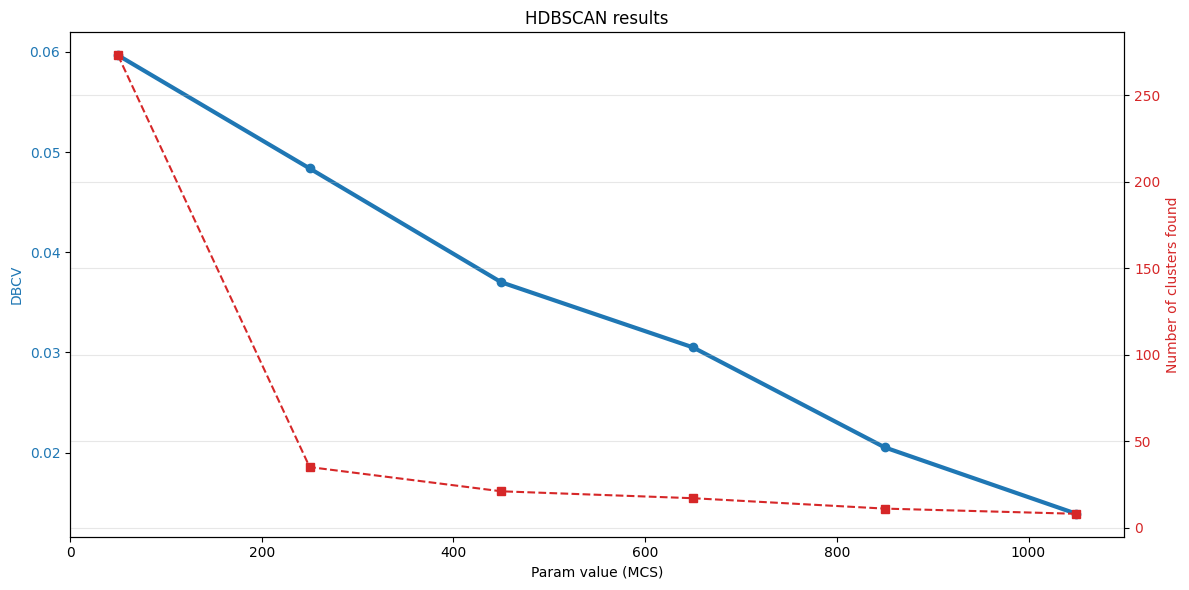

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tr_sinu_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │         6 │    3m19s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │         6 │    3m19s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# 32D Time2Vec data, min_samples=1
with cuml.accel.profile():
    exp_tr_1 = ClusterExperimenter(temporal_features_path)
    exp_tr_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tr_1.export_results_csv(os.path.join(LOG_DIR, "exp_tr_sinu_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/t2v_temporal_features.npy ....
Loaded size: (300765, 32)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 32)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 196 | DBCV: 0.0493 | Noise: 13.2% | Time: 27.98 s
[2] Val: 250 | Clusters: 35 | DBCV: 0.0607 | Noise: 16.9% | Time: 28.74 s
[3] Val: 450 | Clusters: 26 | DBCV: 0.0551 | Noise: 17.8% | Time: 28.13 s
[4] Val: 650 | Clusters: 22 | DBCV: 0.0483 | Noise: 18.5% | Time: 28.02 s
[5] Val: 850 | Clusters: 18 | DBCV: 0.0383 | Noise: 19.5% | Time: 28.30 s
[6] Val: 1050 | Clusters: 15 | DBCV: 0.0288 | Noise: 20.5% | Time: 27.81 s
[7] Val: 1250 | Clusters: 10 | DBCV: 0.0137 | Noise: 22.0% | Time: 27.88 s
Target cluster count 10 reached. Stopping.
Total Time: 3.28 m
------------------------------
SWEEP SUMMARY:
Total iterations: 7
Best DBCV: 0.

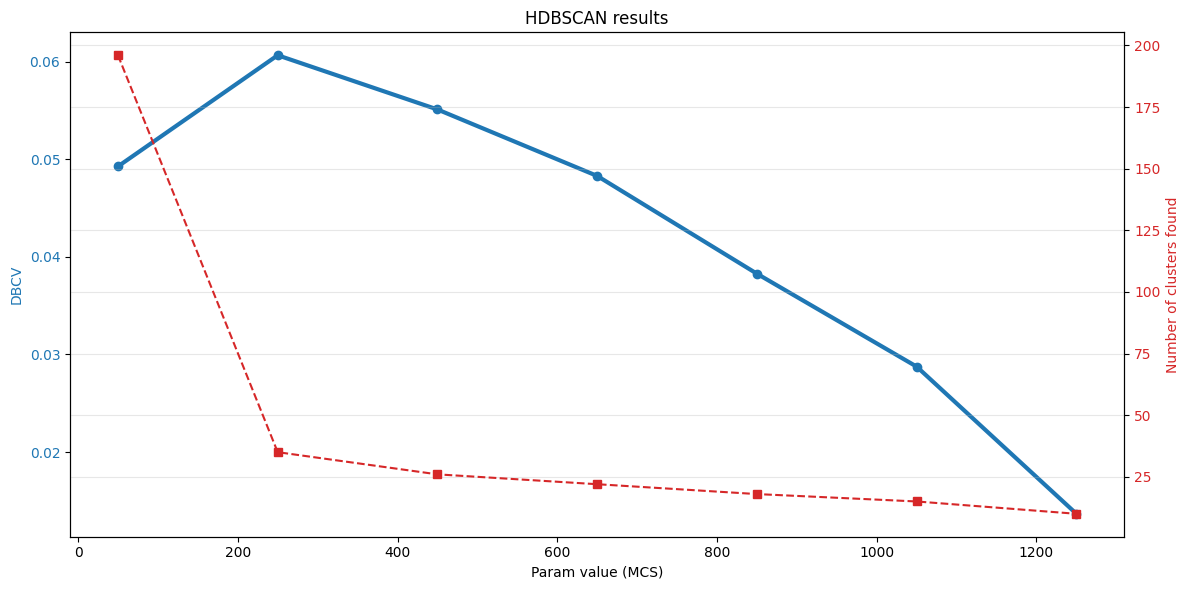

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tr_sinu_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │         7 │  2m12.6s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │         7 │  2m12.6s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# 32D Time2Vec data, min_samples=13
with cuml.accel.profile():
    exp_tr_13 = ClusterExperimenter(temporal_features_path)
    exp_tr_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tr_13.export_results_csv(os.path.join(LOG_DIR, "exp_tr_sinu_13.csv"))

In [ ]:
# 32D Time2Vec data, min_samples=min_cluster_size
# with cuml.accel.profile():
#     exp_tr_na = ClusterExperimenter(temporal_features_path)
#     exp_tr_na.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tr_na.export_results_csv(os.path.join(LOG_DIR, "exp_tr_sinu_na.csv"))

## Days-since-Epoch 2D

In [ ]:
FEATURE_DIR = 'epoch_temporal_features.npy'
temporal_epoch_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

In [ ]:
feature_array = np.load(temporal_epoch_features_path)
feature_array.shape

(300765, 2)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/epoch_temporal_features.npy ....
Loaded size: (300765, 2)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 2)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 384 | DBCV: 0.0561 | Noise: 9.7% | Time: 42.95 s
[2] Val: 250 | Clusters: 85 | DBCV: 0.0486 | Noise: 15.8% | Time: 41.64 s
[3] Val: 450 | Clusters: 64 | DBCV: 0.0371 | Noise: 17.3% | Time: 42.28 s
[4] Val: 650 | Clusters: 50 | DBCV: 0.0250 | Noise: 18.9% | Time: 41.87 s
[5] Val: 850 | Clusters: 41 | DBCV: 0.0418 | Noise: 19.7% | Time: 42.51 s
[6] Val: 1050 | Clusters: 34 | DBCV: 0.0322 | Noise: 20.4% | Time: 42.66 s
[7] Val: 1250 | Clusters: 31 | DBCV: 0.0358 | Noise: 20.8% | Time: 43.44 s
[8] Val: 1450 | Clusters: 27 | DBCV: 0.0632 | Noise: 21.0% | Time: 43.47 s
[9] Val: 1650 | Clusters: 26 | DBCV: 0.0582 | Noise: 21.5% | Time: 4

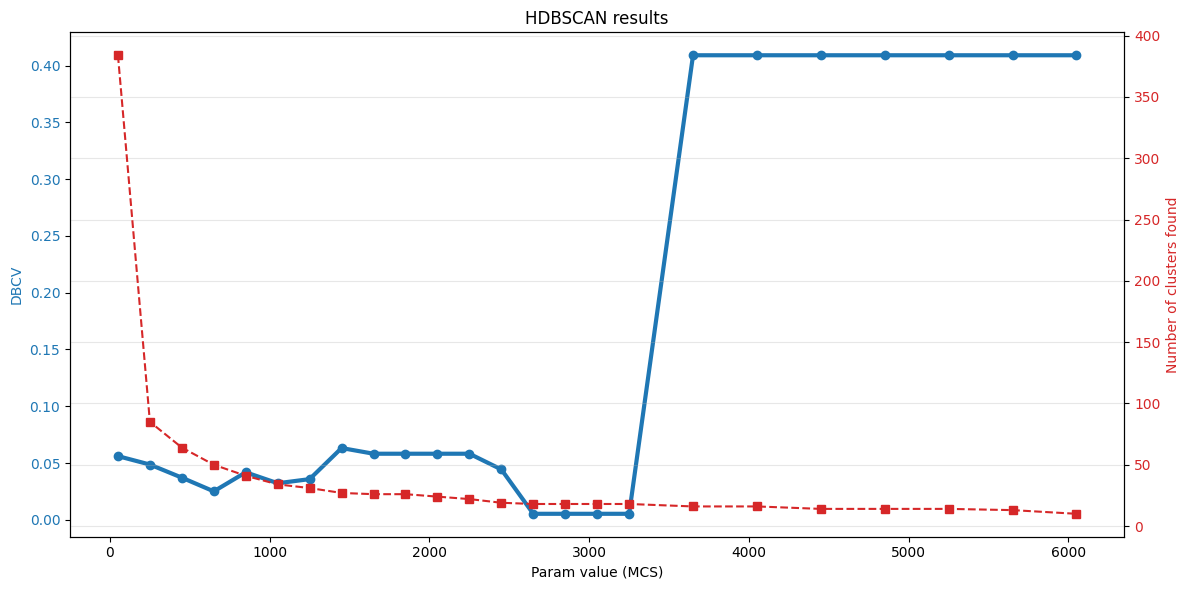

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tre_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        24 │ 13m41.1s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        24 │ 13m41.1s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# 2D epoch data, min_samples=1
with cuml.accel.profile():
    exp_tre_1 = ClusterExperimenter(temporal_epoch_features_path)
    exp_tre_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tre_1.export_results_csv(os.path.join(LOG_DIR, "exp_tre_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/epoch_temporal_features.npy ....
Loaded size: (300765, 2)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 2)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 454 | DBCV: 0.0549 | Noise: 14.5% | Time: 21.69 s
[2] Val: 250 | Clusters: 140 | DBCV: 0.0407 | Noise: 18.6% | Time: 22.15 s
[3] Val: 450 | Clusters: 100 | DBCV: 0.0465 | Noise: 19.2% | Time: 21.51 s
[4] Val: 650 | Clusters: 72 | DBCV: 0.0561 | Noise: 20.4% | Time: 21.36 s
[5] Val: 850 | Clusters: 61 | DBCV: 0.0661 | Noise: 21.2% | Time: 21.53 s
[6] Val: 1050 | Clusters: 53 | DBCV: 0.0680 | Noise: 21.5% | Time: 20.97 s
[7] Val: 1250 | Clusters: 47 | DBCV: 0.0680 | Noise: 21.5% | Time: 21.05 s
[8] Val: 1450 | Clusters: 42 | DBCV: 0.0661 | Noise: 21.8% | Time: 20.69 s
[9] Val: 1650 | Clusters: 36 | DBCV: 0.0284 | Noise: 21.8% | Tim

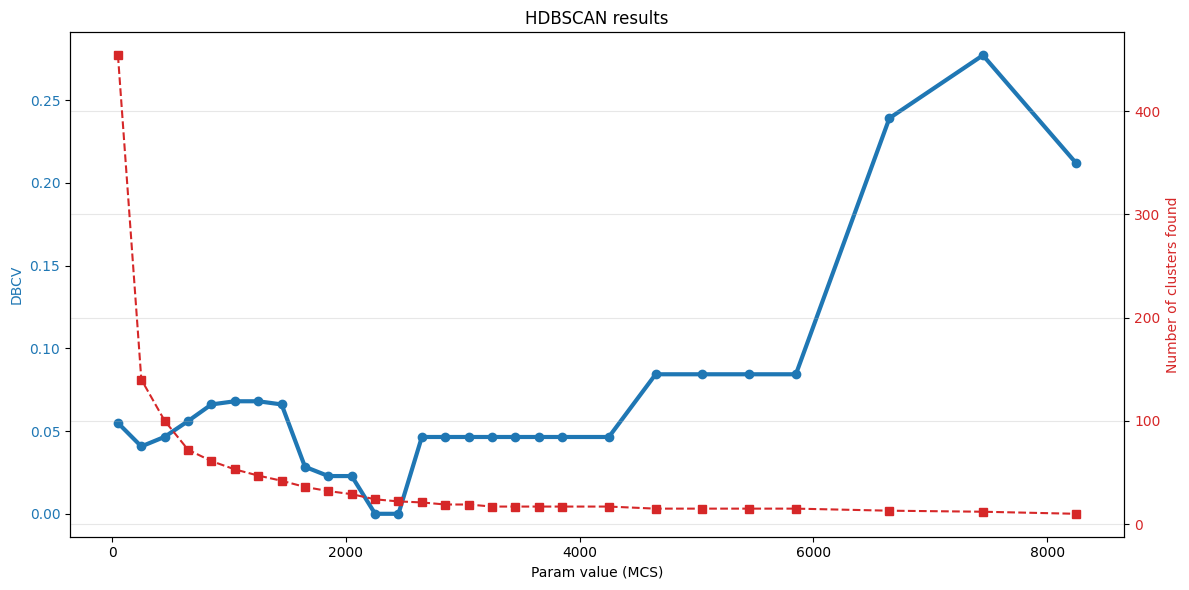

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tre_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        28 │  5m33.8s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        28 │  5m33.8s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# 2D epoch data, min_samples=13
with cuml.accel.profile():
    exp_tre_13 = ClusterExperimenter(temporal_epoch_features_path)
    exp_tre_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tre_13.export_results_csv(os.path.join(LOG_DIR, "exp_tre_13.csv"))

In [ ]:
# 2D epoch data, min_samples=None
# with cuml.accel.profile():
#     exp_tre_na = ClusterExperimenter(temporal_epoch_features_path)
#     exp_tre_na.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tre_na.export_results_csv(os.path.join(LOG_DIR, "exp_tre_na.csv"))

# Topical + Spatial

In [ ]:
TOPICAL_FEATURE_DIR = 'topical_features.npy'
SPATIAL_FEATURE_DIR = 'sinu_spatial_features.npy'
topical_features_path = os.path.join(PROCESSED_DATA_DIR, TOPICAL_FEATURE_DIR)
spatial_features_path = os.path.join(PROCESSED_DATA_DIR, SPATIAL_FEATURE_DIR)

## Data Preparation

In [ ]:
spatial_features_array = np.load(spatial_features_path)
print(f"Spatial features shape: {spatial_features_array.shape}")

Spatial features shape: (300765, 4)


In [ ]:
# UMAP reduction on topical to 30D
exp_topical = ClusterExperimenter(topical_features_path)
topical_30d_array = exp_topical.run_umap(
    dim=30,
    n_neighbors=200,
    metric='cosine',
    should_normalize=True)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 30 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 30)


In [ ]:
# Verify value range after reduction and normalization
tp_range = topical_30d_array.max() - topical_30d_array.min()
sp_range = spatial_features_array.max() - spatial_features_array.min()
print(f"Topical range: {tp_range:.2f}")
print(f"Spatial range: {sp_range:.2f}")

Topical range: 1.99
Spatial range: 2.00


In [ ]:
spatial_weight = np.sqrt(30 / 4)

tp_sp_array = np.hstack([topical_30d_array, spatial_features_array * spatial_weight])
tp_sp_array.shape

(300765, 34)

In [ ]:
TP_SP_FILE = 'topical_spatial_features.npy'
np.save(os.path.join(PROCESSED_DATA_DIR, TP_SP_FILE), tp_sp_array)

print(f"Topical + Spatial feature array saved!")

Topical + Spatial feature array saved!


## Param Sweep

In [ ]:
FEATURE_DIR = 'topical_spatial_features.npy'
topical_spatial_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_spatial_features.npy ....
Loaded size: (300765, 34)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 34)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1772 | DBCV: 0.3264 | Noise: 19.3% | Time: 2.34 m
[2] Val: 250 | Clusters: 367 | DBCV: 0.2227 | Noise: 29.6% | Time: 2.34 m
[3] Val: 450 | Clusters: 168 | DBCV: 0.1908 | Noise: 35.0% | Time: 2.34 m
[4] Val: 650 | Clusters: 108 | DBCV: 0.1973 | Noise: 36.6% | Time: 2.35 m
[5] Val: 850 | Clusters: 79 | DBCV: 0.2027 | Noise: 37.1% | Time: 2.35 m
[6] Val: 1050 | Clusters: 70 | DBCV: 0.2022 | Noise: 37.6% | Time: 2.34 m
[7] Val: 1250 | Clusters: 55 | DBCV: 0.2381 | Noise: 39.8% | Time: 2.34 m
[8] Val: 1450 | Clusters: 49 | DBCV: 0.2559 | Noise: 41.1% | Time: 2.34 m
[9] Val: 1650 | Clusters: 42 | DBCV: 0.2286 | Noise: 41.3% | Time: 2

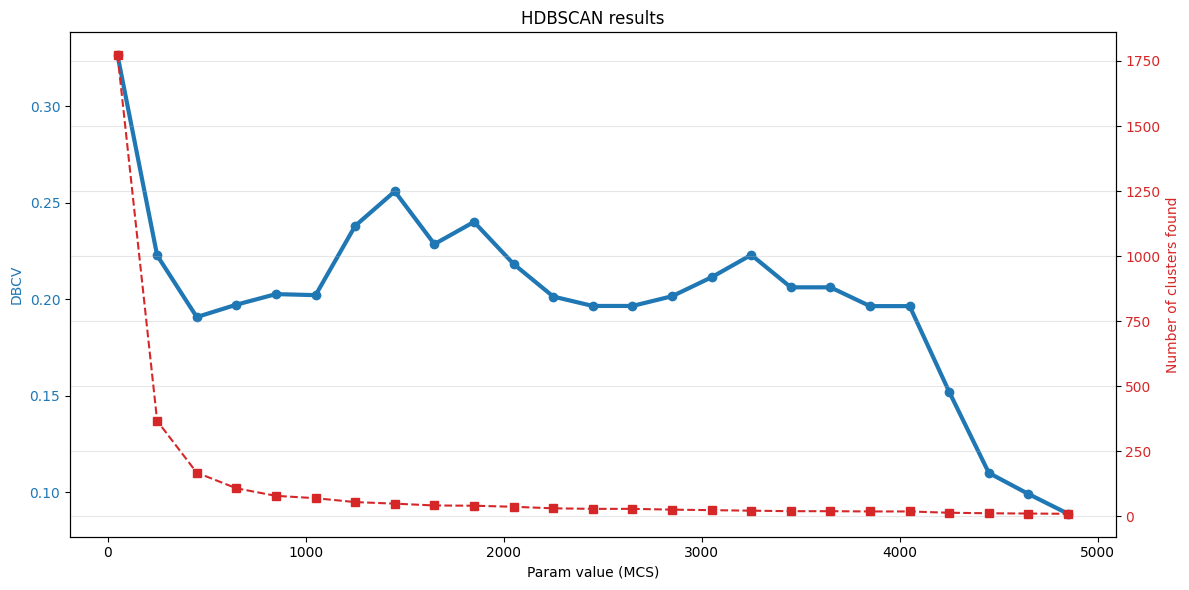

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_sp_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        25 │ 54m36.7s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        25 │ 54m36.7s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Topical + Spatial 34D, min_samples=1
with cuml.accel.profile():
    exp_tp_sp_1 = ClusterExperimenter(topical_spatial_features_path)
    exp_tp_sp_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_sp_1.export_results_csv(os.path.join(LOG_DIR, "exp_tp_sp_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_spatial_features.npy ....
Loaded size: (300765, 34)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 34)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1410 | DBCV: 0.3081 | Noise: 31.5% | Time: 35.92 s
[2] Val: 250 | Clusters: 291 | DBCV: 0.2448 | Noise: 45.1% | Time: 35.56 s
[3] Val: 450 | Clusters: 121 | DBCV: 0.1896 | Noise: 54.9% | Time: 35.65 s
[4] Val: 650 | Clusters: 73 | DBCV: 0.2164 | Noise: 57.2% | Time: 35.59 s
[5] Val: 850 | Clusters: 56 | DBCV: 0.2057 | Noise: 60.4% | Time: 36.08 s
[6] Val: 1050 | Clusters: 47 | DBCV: 0.1899 | Noise: 61.7% | Time: 35.57 s
[7] Val: 1250 | Clusters: 39 | DBCV: 0.1648 | Noise: 63.9% | Time: 35.08 s
[8] Val: 1450 | Clusters: 31 | DBCV: 0.1444 | Noise: 61.7% | Time: 36.15 s
[9] Val: 1650 | Clusters: 24 | DBCV: 0.1225 | Noise: 53.6% |

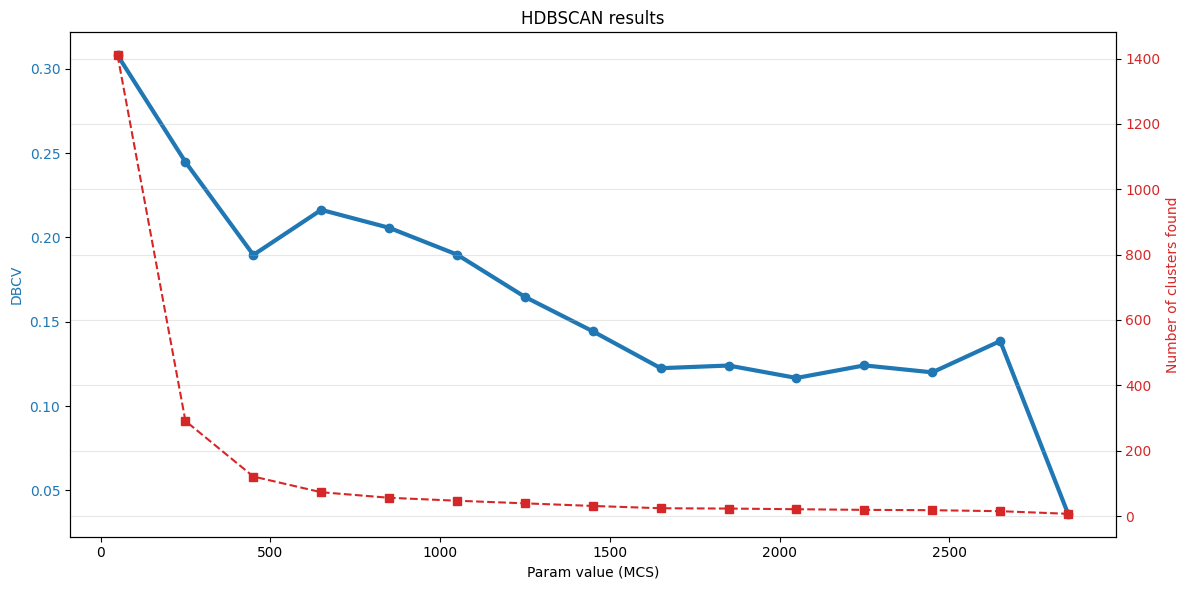

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_sp_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        15 │    6m42s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        15 │    6m42s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Topical + Spatial 34D, min_samples=13
with cuml.accel.profile():
    exp_tp_sp_13 = ClusterExperimenter(topical_spatial_features_path)
    exp_tp_sp_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tp_sp_13.export_results_csv(os.path.join(LOG_DIR, "exp_tp_sp_13.csv"))

In [ ]:
# Topical + Spatial 34D, min_samples=None
# with cuml.accel.profile():
#     exp_tp_sp_na = ClusterExperimenter(topical_spatial_features_path)
#     exp_tp_sp_na.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tp_sp_na.export_results_csv(os.path.join(LOG_DIR, "exp_tp_sp_na.csv"))

In [ ]:
# Topical + Spatial, targeted
# with cuml.accel.profile():
#     exp_tp_sp = ClusterExperimenter(topical_spatial_features_path)
#     exp_tp_sp.execute_sweep(param_range=[1600])
#     exp_tp_sp.plot_clusters(exp_tp_sp.best_labels, reducer='umap')

# Topical + Temporal

## Data Preparation

In [ ]:
TOPICAL_FEATURE_DIR = 'topical_features.npy'
TEMPORAL_FEATURE_DIR = 'epoch_temporal_features.npy'
topical_features_path = os.path.join(PROCESSED_DATA_DIR, TOPICAL_FEATURE_DIR)
temporal_features_path = os.path.join(PROCESSED_DATA_DIR, TEMPORAL_FEATURE_DIR)

In [ ]:
temporal_features_array = np.load(temporal_features_path)
print(f"Temporal features shape: {temporal_features_array.shape}")

Temporal features shape: (300765, 2)


In [ ]:
# UMAP reduction on topical to 30D
exp_topical = ClusterExperimenter(topical_features_path)
topical_30d_array = exp_topical.run_umap(
    dim=30,
    n_neighbors=200,
    metric='cosine',
    should_normalize=True)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 30 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 30)


In [ ]:
# Verify value range after reduction and normalization
tp_range = topical_30d_array.max() - topical_30d_array.min()
tr_range = temporal_features_array.max() - temporal_features_array.min()
print(f"Topical range: {tp_range:.2f}")
print(f"Temporal range: {tr_range:.2f}")

Topical range: 1.99
Temporal range: 2.00


In [ ]:
temporal_weight = np.sqrt(30 / 2)

tp_tr_array = np.hstack([topical_30d_array, temporal_features_array * temporal_weight])
tp_tr_array.shape

(300765, 32)

In [ ]:
TP_TR_FILE = 'topical_temporal_features.npy'
np.save(os.path.join(PROCESSED_DATA_DIR, TP_TR_FILE), tp_tr_array)

print(f"Topical + Temporal feature array saved!")

Topical + Temporal feature array saved!


## Param Sweep

In [ ]:
FEATURE_DIR = 'topical_temporal_features.npy'
topical_temporal_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

In [ ]:
# Topical + Spatial 34D, min_samples=None
# with cuml.accel.profile():
#     exp_tp_tr_na = ClusterExperimenter(topical_temporal_features_path)
#     exp_tp_tr_na.execute_sweep(val=50, step=200, target_n_clusters=10)
#     exp_tp_tr_na.export_results_csv(os.path.join(LOG_DIR, "exp_tp_tr_na.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_temporal_features.npy ....
Loaded size: (300765, 32)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 32)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1945 | DBCV: 0.3213 | Noise: 18.9% | Time: 2.00 m
[2] Val: 250 | Clusters: 360 | DBCV: 0.2668 | Noise: 29.3% | Time: 1.97 m
[3] Val: 450 | Clusters: 166 | DBCV: 0.2479 | Noise: 34.0% | Time: 2.00 m
[4] Val: 650 | Clusters: 115 | DBCV: 0.2592 | Noise: 35.8% | Time: 1.98 m
[5] Val: 850 | Clusters: 82 | DBCV: 0.2822 | Noise: 37.4% | Time: 1.99 m
[6] Val: 1050 | Clusters: 63 | DBCV: 0.2903 | Noise: 39.5% | Time: 2.00 m
[7] Val: 1250 | Clusters: 49 | DBCV: 0.2732 | Noise: 38.4% | Time: 1.97 m
[8] Val: 1450 | Clusters: 42 | DBCV: 0.2684 | Noise: 40.4% | Time: 2.00 m
[9] Val: 1650 | Clusters: 39 | DBCV: 0.2863 | Noise: 41.5% | Time: 

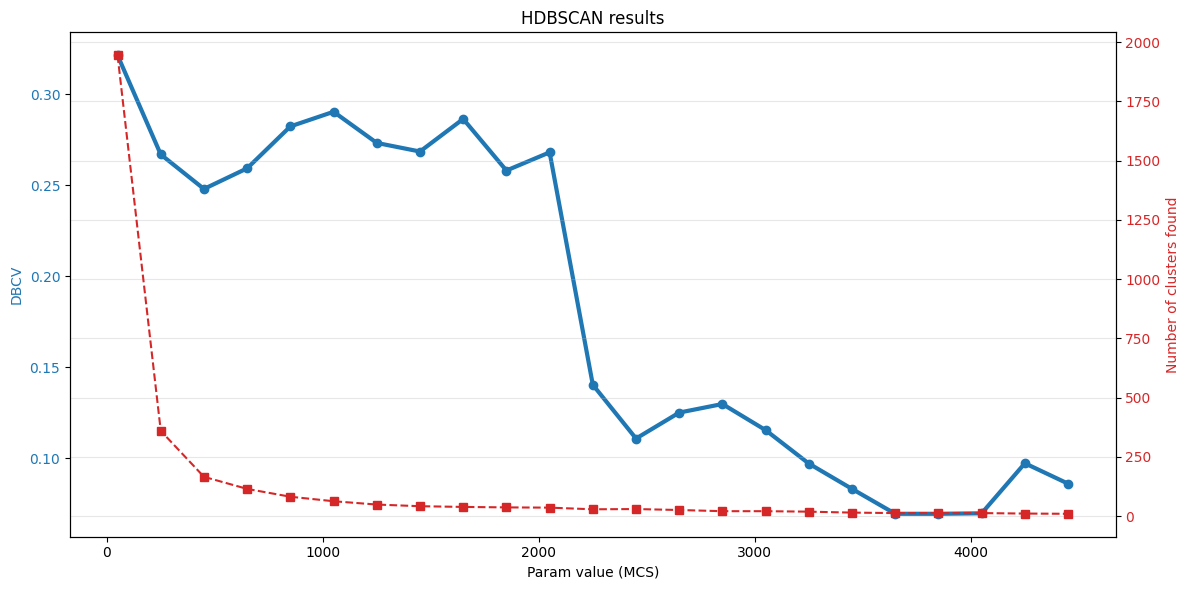

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_tr_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        23 │   42m21s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        23 │   42m21s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Topical + Spatial 34D, min_samples=1
with cuml.accel.profile():
    exp_tp_tr_1 = ClusterExperimenter(topical_temporal_features_path)
    exp_tp_tr_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_tp_tr_1.export_results_csv(os.path.join(LOG_DIR, "exp_tp_tr_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_temporal_features.npy ....
Loaded size: (300765, 32)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 32)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1529 | DBCV: 0.3397 | Noise: 28.1% | Time: 32.00 s
[2] Val: 250 | Clusters: 295 | DBCV: 0.2498 | Noise: 42.5% | Time: 34.46 s
[3] Val: 450 | Clusters: 124 | DBCV: 0.3118 | Noise: 45.6% | Time: 32.37 s
[4] Val: 650 | Clusters: 85 | DBCV: 0.3049 | Noise: 42.1% | Time: 32.25 s
[5] Val: 850 | Clusters: 61 | DBCV: 0.3063 | Noise: 46.6% | Time: 33.28 s
[6] Val: 1050 | Clusters: 50 | DBCV: 0.2036 | Noise: 52.9% | Time: 32.07 s
[7] Val: 1250 | Clusters: 41 | DBCV: 0.2978 | Noise: 49.4% | Time: 32.76 s
[8] Val: 1450 | Clusters: 31 | DBCV: 0.3127 | Noise: 52.1% | Time: 33.10 s
[9] Val: 1650 | Clusters: 22 | DBCV: 0.1503 | Noise: 33.2% 

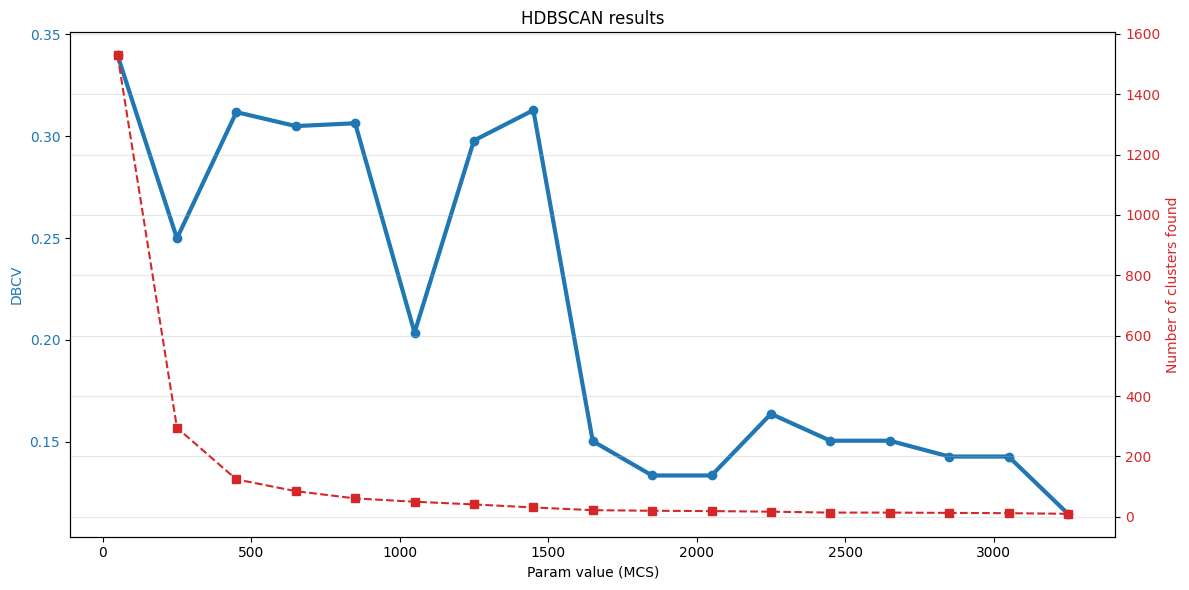

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_tp_tr_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        17 │  6m45.7s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        17 │  6m45.7s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# Topical + Spatial 34D, min_samples=13
with cuml.accel.profile():
    exp_tp_tr_13 = ClusterExperimenter(topical_temporal_features_path)
    exp_tp_tr_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_tp_tr_13.export_results_csv(os.path.join(LOG_DIR, "exp_tp_tr_13.csv"))

# Topical + Spatial + Temporal

## Data Preparation

In [ ]:
TOPICAL_FEATURE_DIR = 'topical_features.npy'
SPATIAL_FEATURE_DIR = 'sinu_spatial_features.npy'
TEMPORAL_FEATURE_DIR = 'epoch_temporal_features.npy'
topical_features_path = os.path.join(PROCESSED_DATA_DIR, TOPICAL_FEATURE_DIR)
spatial_features_path = os.path.join(PROCESSED_DATA_DIR, SPATIAL_FEATURE_DIR)
temporal_features_path = os.path.join(PROCESSED_DATA_DIR, TEMPORAL_FEATURE_DIR)

In [ ]:
spatial_features_array = np.load(spatial_features_path)
print(f"Spatial features shape: {spatial_features_array.shape}")

temporal_features_array = np.load(temporal_features_path)
print(f"Temporal features shape: {temporal_features_array.shape}")

Spatial features shape: (300765, 4)
Temporal features shape: (300765, 2)


In [ ]:
# UMAP reduction on topical to 30D
exp_topical = ClusterExperimenter(topical_features_path)
topical_30d_array = exp_topical.run_umap(
    dim=30,
    n_neighbors=200,
    metric='cosine',
    should_normalize=True)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/topical_features.npy ....
Loaded size: (300765, 768)
Performing UMAP, reducing to 10 with n_neighnors 200, metric cosine ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 10)


In [ ]:
# Verify value range after reduction and normalization
tp_range = topical_30d_array.max() - topical_30d_array.min()
sp_range = spatial_features_array.max() - spatial_features_array.min()
tr_range = temporal_features_array.max() - temporal_features_array.min()
print(f"Topical range: {tp_range:.2f}")
print(f"Spatial range: {sp_range:.2f}")
print(f"Temporal range: {tr_range:.2f}")

Topical range: 1.99
Spatial range: 2.00
Temporal range: 2.00


In [ ]:
temporal_weight = np.sqrt(30 / 2)
spatial_weight = np.sqrt(30 / 4)

tp_sp_tr_array = np.hstack([
    topical_30d_array,
    spatial_features_array * spatial_weight,
    temporal_features_array * temporal_weight])

tp_sp_tr_array.shape

(300765, 16)

In [ ]:
TP_SP_TR_FILE = 'tp10_all_features.npy'
np.save(os.path.join(PROCESSED_DATA_DIR, TP_SP_TR_FILE), tp_sp_tr_array)

print(f"All combined feature array saved!")

All combined feature array saved!


## Param Sweep

In [ ]:
FEATURE_DIR = 'all_features.npy'
all_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

In [ ]:
# All features 36D, min_samples=None
# with cuml.accel.profile():
#     exp_all_na = ClusterExperimenter(all_features_path)
#     exp_all_na.execute_sweep(val=50, step=200, target_n_clusters=10)

# Highest peak, but 106 clusters and more than 20% noise

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 36)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1945 | DBCV: 0.2498 | Noise: 20.0% | Time: 3.21 m
[2] Val: 250 | Clusters: 378 | DBCV: 0.2309 | Noise: 31.1% | Time: 3.26 m
[3] Val: 450 | Clusters: 178 | DBCV: 0.2107 | Noise: 39.4% | Time: 3.27 m
[4] Val: 650 | Clusters: 116 | DBCV: 0.2175 | Noise: 42.4% | Time: 3.30 m
[5] Val: 850 | Clusters: 82 | DBCV: 0.1909 | Noise: 48.2% | Time: 3.28 m
[6] Val: 1050 | Clusters: 66 | DBCV: 0.1679 | Noise: 46.9% | Time: 3.28 m
[7] Val: 1250 | Clusters: 59 | DBCV: 0.1686 | Noise: 52.0% | Time: 3.29 m
[8] Val: 1450 | Clusters: 47 | DBCV: 0.1396 | Noise: 56.4% | Time: 3.30 m
[9] Val: 1650 | Clusters: 35 | DBCV: 0.0908 | Noise: 54.3% | Time: 3.31 m
[10] V

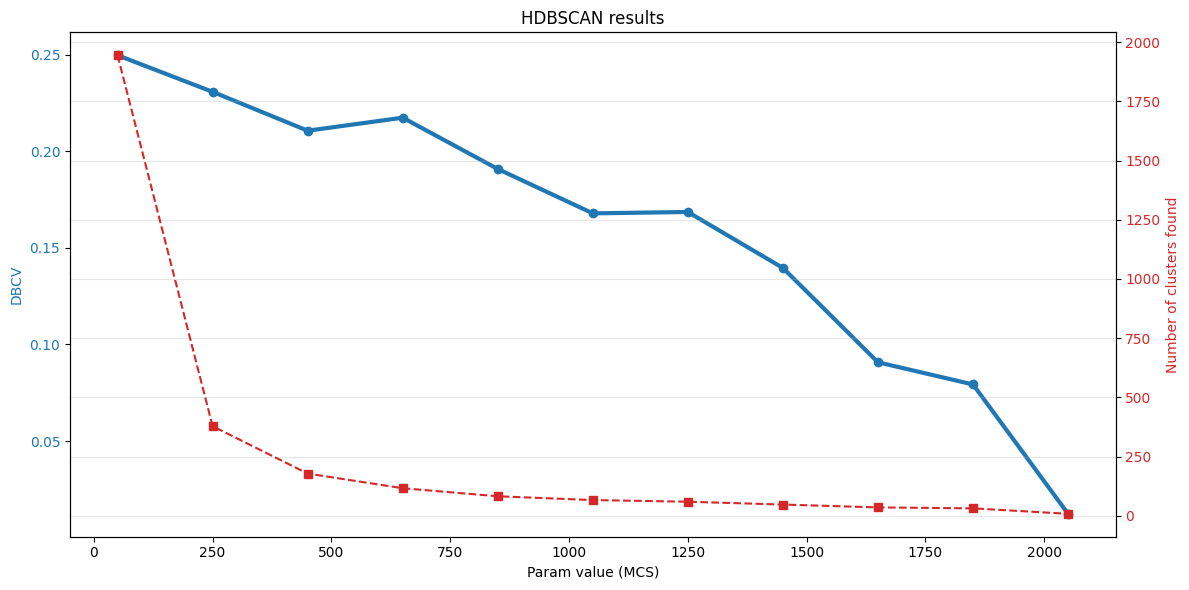

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        11 │ 34m23.3s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        11 │ 34m23.3s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# All features 36D, min_samples=1
with cuml.accel.profile():
    exp_all_1 = ClusterExperimenter(all_features_path)
    exp_all_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_all_1.export_results_csv(os.path.join(LOG_DIR, "exp_all_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 36)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1418 | DBCV: 0.2761 | Noise: 35.9% | Time: 31.06 s
[2] Val: 250 | Clusters: 270 | DBCV: 0.2621 | Noise: 47.9% | Time: 32.67 s
[3] Val: 450 | Clusters: 113 | DBCV: 0.2086 | Noise: 57.3% | Time: 31.91 s
[4] Val: 650 | Clusters: 71 | DBCV: 0.1491 | Noise: 58.8% | Time: 31.55 s
[5] Val: 850 | Clusters: 51 | DBCV: 0.1852 | Noise: 60.5% | Time: 30.29 s
[6] Val: 1050 | Clusters: 41 | DBCV: 0.1776 | Noise: 62.9% | Time: 30.81 s
[7] Val: 1250 | Clusters: 33 | DBCV: 0.2251 | Noise: 63.8% | Time: 31.92 s
[8] Val: 1450 | Clusters: 26 | DBCV: 0.2033 | Noise: 65.4% | Time: 31.94 s
[9] Val: 1650 | Clusters: 23 | DBCV: 0.1943 | Noise: 65.3% | Time: 30.76

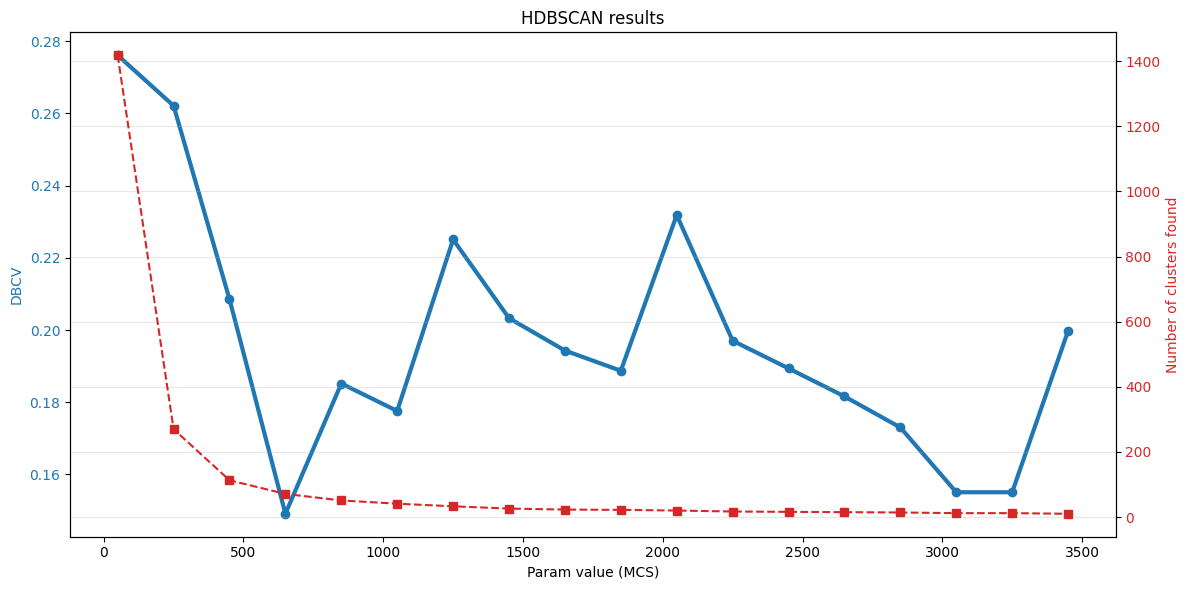

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        18 │  6m34.5s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        18 │  6m34.5s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# All features 36D, min_samples=13
with cuml.accel.profile():
    exp_all_13 = ClusterExperimenter(all_features_path)
    exp_all_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_all_13.export_results_csv(os.path.join(LOG_DIR, "exp_all_13.csv"))

In [ ]:
FEATURE_DIR = 'tp10_all_features.npy'
tp10_all_features_path = os.path.join(PROCESSED_DATA_DIR, FEATURE_DIR)

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/tp10_all_features.npy ....
Loaded size: (300765, 16)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 16)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 13
[1] Val: 50 | Clusters: 1484 | DBCV: 0.2947 | Noise: 32.6% | Time: 35.72 s
[2] Val: 250 | Clusters: 272 | DBCV: 0.2111 | Noise: 49.8% | Time: 36.34 s
[3] Val: 450 | Clusters: 109 | DBCV: 0.1779 | Noise: 58.6% | Time: 24.61 s
[4] Val: 650 | Clusters: 64 | DBCV: 0.1723 | Noise: 57.2% | Time: 36.51 s
[5] Val: 850 | Clusters: 52 | DBCV: 0.1853 | Noise: 58.5% | Time: 28.07 s
[6] Val: 1050 | Clusters: 42 | DBCV: 0.1714 | Noise: 61.0% | Time: 24.22 s
[7] Val: 1250 | Clusters: 36 | DBCV: 0.2433 | Noise: 61.0% | Time: 23.43 s
[8] Val: 1450 | Clusters: 30 | DBCV: 0.2408 | Noise: 63.2% | Time: 24.19 s
[9] Val: 1650 | Clusters: 21 | DBCV: 0.1964 | Noise: 62.6% | Time: 

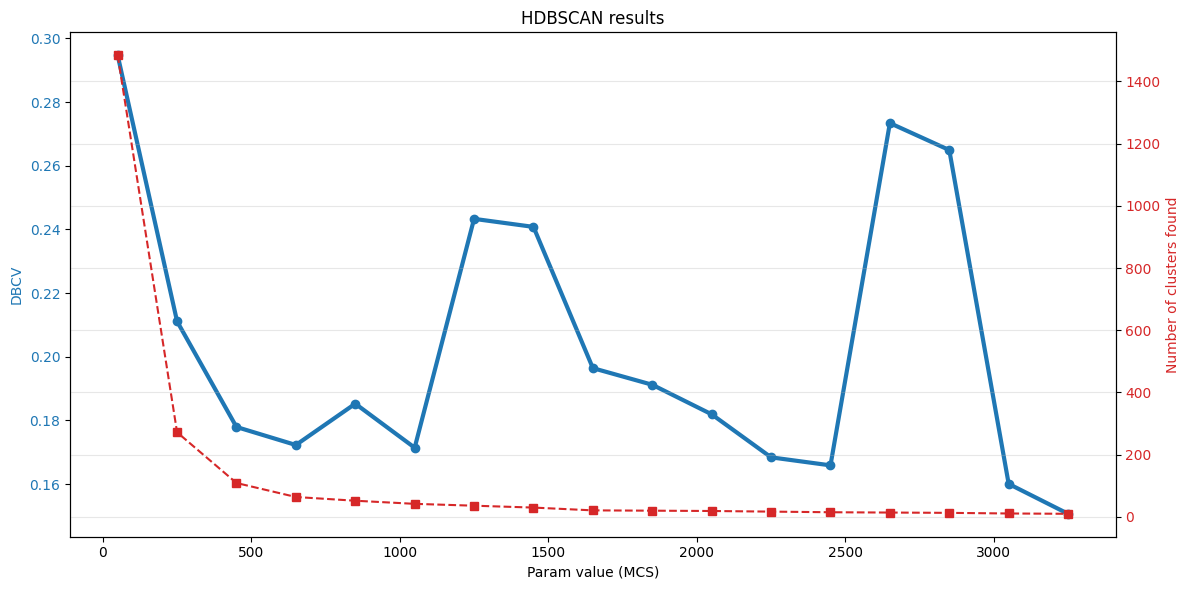

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_tp10_13.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        17 │  4m10.5s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        17 │  4m10.5s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
with cuml.accel.profile():
    exp_all_tp10_13 = ClusterExperimenter(tp10_all_features_path)
    exp_all_tp10_13.execute_sweep(val=50, step=200, min_samples=13, target_n_clusters=10)
    exp_all_tp10_13.export_results_csv(os.path.join(LOG_DIR, "exp_all_tp10_13.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 36)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 1
[1] Val: 50 | Clusters: 1946 | DBCV: 0.2567 | Noise: 20.0% | Time: 3.27 m
[2] Val: 250 | Clusters: 377 | DBCV: 0.2201 | Noise: 31.4% | Time: 3.30 m
[3] Val: 450 | Clusters: 179 | DBCV: 0.2127 | Noise: 38.7% | Time: 3.31 m
[4] Val: 650 | Clusters: 114 | DBCV: 0.2054 | Noise: 42.3% | Time: 3.31 m
[5] Val: 850 | Clusters: 80 | DBCV: 0.1731 | Noise: 43.5% | Time: 3.30 m
[6] Val: 1050 | Clusters: 67 | DBCV: 0.1714 | Noise: 44.8% | Time: 3.29 m
[7] Val: 1250 | Clusters: 57 | DBCV: 0.1744 | Noise: 52.3% | Time: 3.28 m
[8] Val: 1450 | Clusters: 45 | DBCV: 0.1299 | Noise: 57.9% | Time: 3.28 m
[9] Val: 1650 | Clusters: 35 | DBCV: 0.0900 | Noise: 54.7% | Time: 3.28 m
[10] V

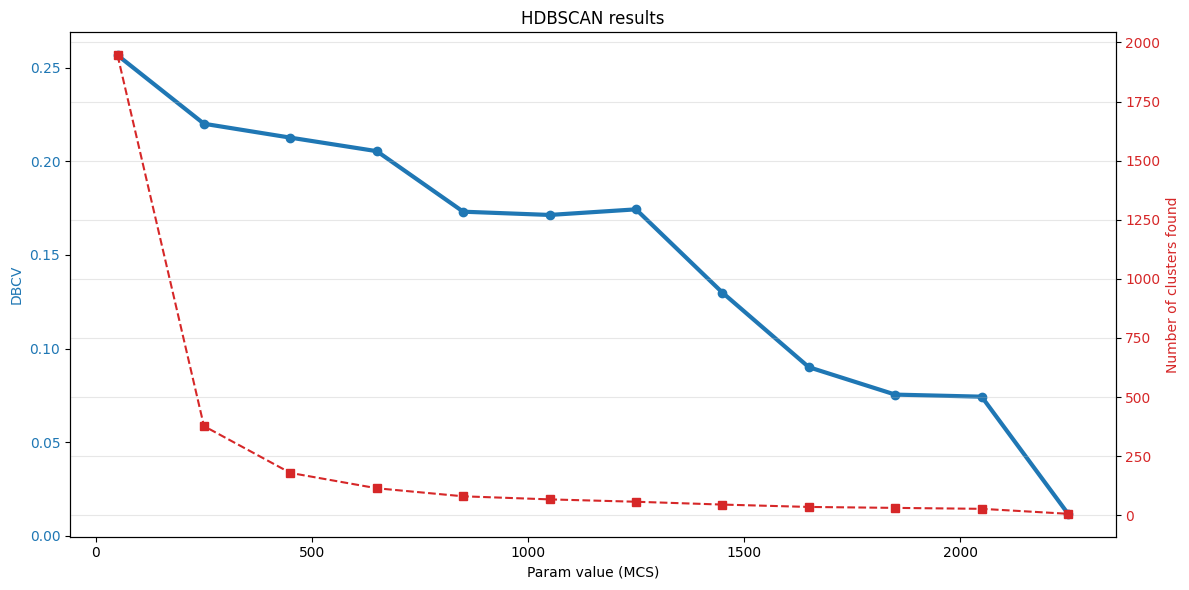

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_tp10_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        12 │ 37m35.6s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        12 │ 37m35.6s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
with cuml.accel.profile():
    exp_all_tp10_1 = ClusterExperimenter(all_features_path)
    exp_all_tp10_1.execute_sweep(val=50, step=200, min_samples=1, target_n_clusters=10)
    exp_all_tp10_1.export_results_csv(os.path.join(LOG_DIR, "exp_all_tp10_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
Performing UMAP, reducing to 2 with n_neighnors 200, metric euclidean ....
Normalizing data ....
Type: <class 'numpy.ndarray'>
Reduced size: (300765, 2)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 2)
Value Type:  float32
------------------------------
Run sweep from val 50 with step 200, min_samples 5


/usr/local/lib/python3.12/dist-packages/hdbscan/hdbscan_.py:1667: RuntimeWarning: invalid value encountered in scalar divide
  (DSPC_wrt[i] - DSC[i]) / max(DSPC_wrt[i], DSC[i])


[1] Val: 50 | Clusters: 2 | DBCV: nan | Noise: 0.0% | Time: 21.26 s
Target cluster count 10 reached. Stopping.
Total Time: 21.26 s
------------------------------
SWEEP SUMMARY:
Total iterations: 1
Best DBCV: -1.0000 with None
Average DBCV: nan


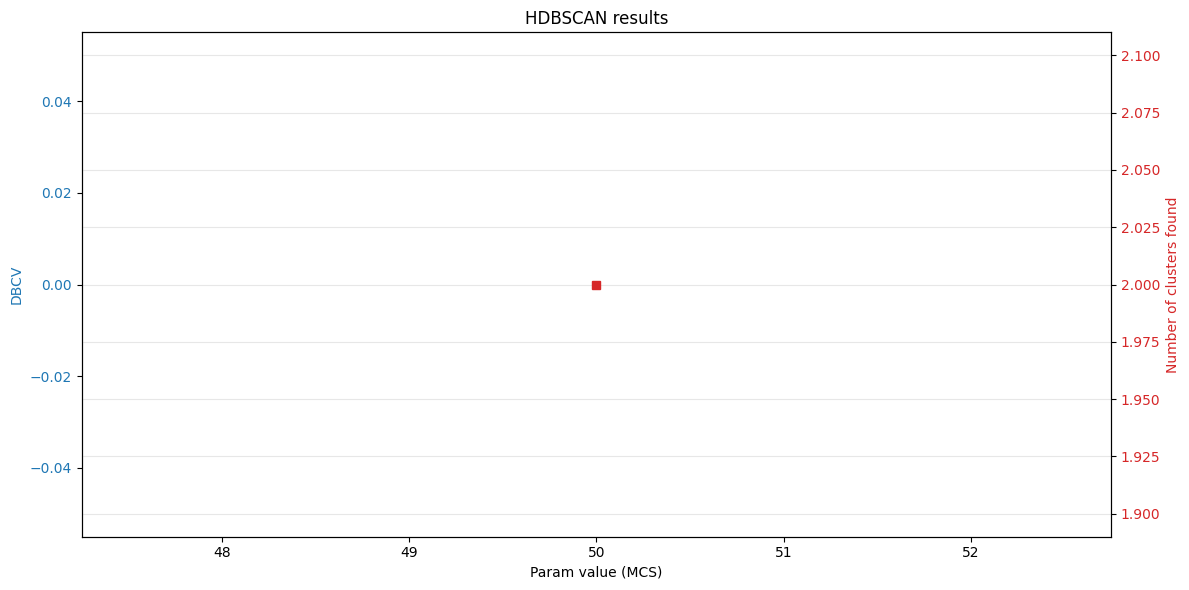

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_umap_2d_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │         1 │    11.4s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │         1 │    11.4s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
with cuml.accel.profile():
    exp_all_umap_2d_1 = ClusterExperimenter(all_features_path)
    exp_all_umap_2d_1.run_umap(dim=2, n_neighbors=200, should_normalize=True)
    exp_all_umap_2d_1.execute_sweep(val=50, step=200, min_samples=5, target_n_clusters=10)
    exp_all_umap_2d_1.export_results_csv(os.path.join(LOG_DIR, "exp_all_umap_2d_1.csv"))

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
Performing PCA, reducing to 2 ....
Reduced size: (300765, 2)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 2)
Value Type:  float64
------------------------------
Run sweep from val 50 with step 200, min_samples 5
[1] Val: 50 | Clusters: 1487 | DBCV: 0.2479 | Noise: 37.5% | Time: 22.33 s
[2] Val: 250 | Clusters: 251 | DBCV: 0.2257 | Noise: 46.2% | Time: 20.54 s
[3] Val: 450 | Clusters: 142 | DBCV: 0.2387 | Noise: 51.2% | Time: 21.71 s
[4] Val: 650 | Clusters: 70 | DBCV: 0.3655 | Noise: 39.1% | Time: 20.30 s
[5] Val: 850 | Clusters: 27 | DBCV: 0.1816 | Noise: 32.2% | Time: 22.47 s
[6] Val: 1050 | Clusters: 23 | DBCV: 0.1675 | Noise: 29.7% | Time: 20.20 s
[7] Val: 1250 | Clusters: 22 | DBCV: 0.0571 | Noise: 35.0% | Time: 21.76 s
[8] Val: 1450 | Clusters: 21 | DBCV: 0.0497 | Noise: 34.3% | Time: 20.26 s
[9] Val: 1650

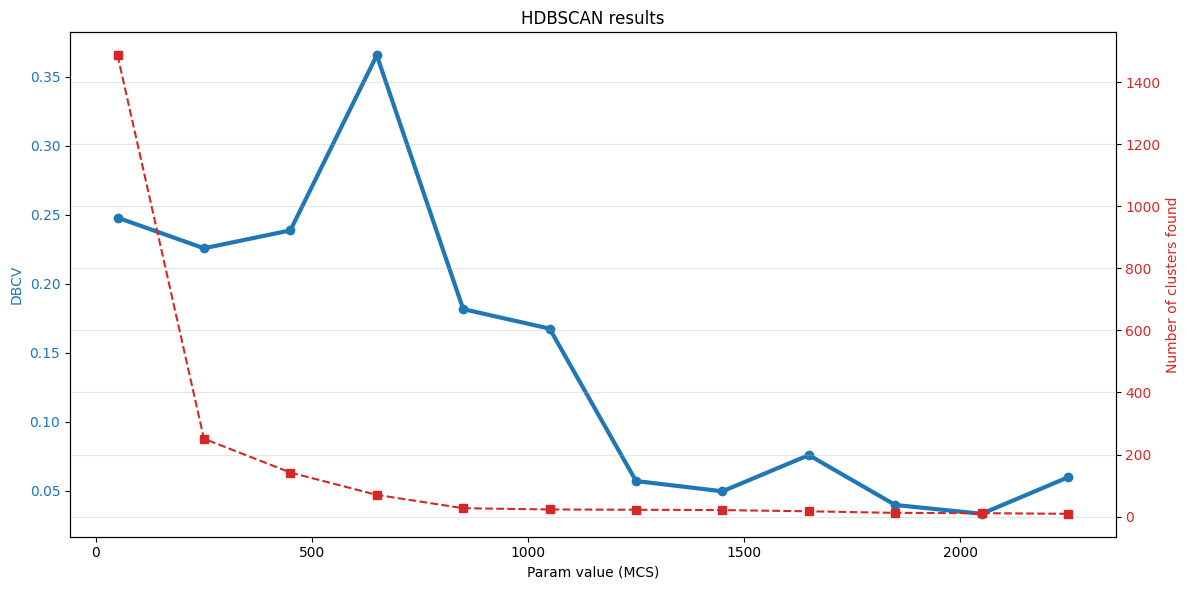

Results exported to /content/drive/MyDrive/TUD-Research_Project/data/processed/Result Logs/exp_all_pca_2d_1.csv


cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │        12 │  2m23.4s │         0 │       0s │
│ PCA.fit_transform   │         1 │     1.1s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │        13 │  2m24.5s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
with cuml.accel.profile():
    exp_all_pca_2d_1 = ClusterExperimenter(all_features_path)
    exp_all_pca_2d_1.run_pca(dim=2)
    exp_all_pca_2d_1.execute_sweep(val=50, step=200, min_samples=5, target_n_clusters=10)
    exp_all_pca_2d_1.export_results_csv(os.path.join(LOG_DIR, "exp_all_pca_2d_1.csv"))

# Single Test

Loading scaled data from /content/drive/MyDrive/TUD-Research_Project/data/processed/all_features.npy ....
Loaded size: (300765, 36)
------------------------------
Object Type: <class 'numpy.ndarray'>
Dimensions:  (300765, 36)
Value Type:  float64
------------------------------
Run fixed range sweep: [2050] with min_samples 13
[1] Val: 2050 | Clusters: 20 | DBCV: 0.2318 | Noise: 64.7% | Time: 32.99 s
Total Time: 32.99 s
------------------------------
SWEEP SUMMARY:
Total iterations: 1
Best DBCV: 0.2318 with 20
Average DBCV: 0.2318


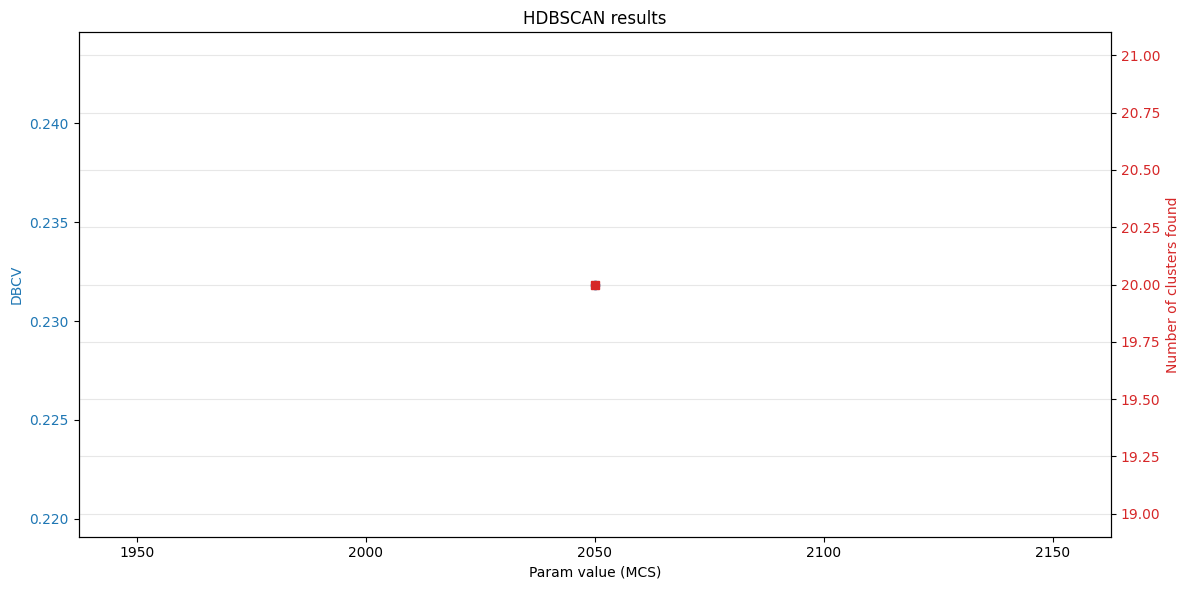

Plotting data ....
Reducing data to 2D using umap


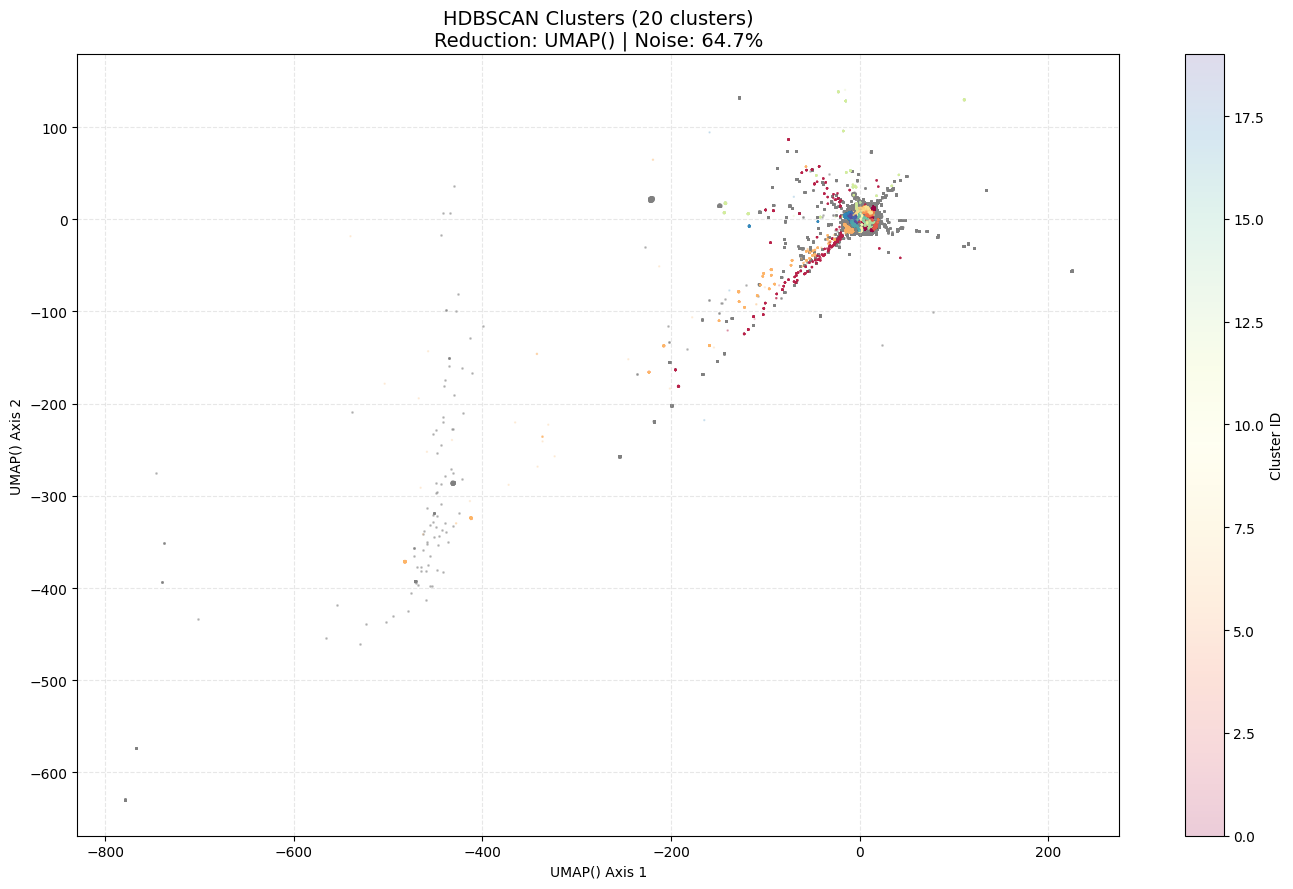

cuml.accel profile                                                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Function            ┃ GPU calls ┃ GPU time ┃ CPU calls ┃ CPU time ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ HDBSCAN.fit_predict │         1 │    23.2s │         0 │       0s │
├─────────────────────┼───────────┼──────────┼───────────┼──────────┤
│ Total               │         1 │    23.2s │         0 │       0s │
└─────────────────────┴───────────┴──────────┴───────────┴──────────┘

In [ ]:
# All features 36D, min_samples=13, Val: 2050
#[11] Val: 2050 | Clusters: 20 | DBCV: 0.2318 | Noise: 64.7% | Time: 31.03 s

with cuml.accel.profile():
    exp_all_13_mcs2050 = ClusterExperimenter(all_features_path)
    exp_all_13_mcs2050.execute_sweep(param_range=[2050], min_samples=13, target_n_clusters=10)
    exp_all_13_mcs2050.plot_clusters(exp_all_13_mcs2050.best_labels, reducer='umap')
    exp_all_13_mcs2050.save_best_result(
        PROCESSED_DATA_DIR + 'cleaned_data.csv',
        PROCESSED_DATA_DIR + 'clustered_data.parquet'
    )